# Reto: Tercer Avance — Spaceship Titanic

# Primer avance

## 1. Carga y comprensión del dataset
*   carga train.csv y test.csv de Spaceship Titanic desde Kaggle.
*   Inspecciona shape, tipos de variables, y primeras filas.
*   Identifica cuál es la variable target y confirma que tipo de problema es.

Nota: Kaggle ya provee train y test separados, no necesitas hacer split. Todo tu trabajo de preparación ocurre sobre train.csv.

In [ ]:
# Carga del dataset crudo desde una ruta relativa local (en lugar de kagglehub),
# siguiendo el mismo criterio de portabilidad adoptado en el Segundo Avance.
# Coloca train.csv y test.csv de la competencia dentro de una carpeta 'data/' junto a este notebook.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency


df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

print(f"Tamaño dataframe train {df_train.shape}")
print(f"Tamaño dataframe test {df_test.shape}")
print(f"Tipos de variables train: \n {df_train.dtypes}")
print(f"Primeras filas train: \n {df_train.head()}")
print(f"Valores únicos por columna train: \n {df_train.nunique()}")

En esta primera parte se cargaron tanto el dataset de entrenamiento como el de prueba. El dataframe de entrenamiento cuenta con 14 columnas (PassengerId, HomePlanet, CryoSleep, Cabin, Destination, Age, VIP, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Name, Transported) y 8693 filas, correspondientes a cada uno de los registros. El dataframe de prueba cuenta con las mismas columnas, excepto Transported, que es nuestra variable objetivo.
Este es un problema de clasificación binaria, es decir, se busca predecir si la persona fue transportada (True) o no (False). Esto se sabe tanto por la descripción del problema como por la ausencia de dicha columna en el dataframe de prueba.
En esta observación inicial se identificaron algunos detalles relevantes:
- Pandas reconoció correctamente el tipo de dato de Transported, pero interpretó CryoSleep y VIP como tipo object, lo que sugiere la presencia de datos faltantes o valores NaN en dichas columnas.
- Al analizar las primeras columnas, en conjunto con la explicación proporcionada por Kaggle, se encontró un patrón entre PassengerID y Cabin: de acuerdo con el identificador de grupo presente en PassengerID, se puede inferir (mas no concluir) que los integrantes de un mismo grupo suelen compartir cabina.
- Se encontraron 8693 valores de PassengerID, cifra que coincide exactamente con el número de filas del dataframe.
- Adicionalmente, se identificaron solo 8473 valores únicos de Name, lo que indica la existencia de valores repetidos (personas distintas con el mismo nombre) y/o valores NaN.
- Finalmente, se buscaron filas duplicadas, no encontrándose ninguna; esto se concluyó a partir de la ausencia de valores duplicados en PassengerID.

##2. Análisis exploratorio (EDA)

* Reporta el porcentaje de faltantes por columna y clasifica cada uno como faltante informativo o faltante real, justificando tu clasificación con el contexto del problema (usa la descripción del dataset en Kaggle).
* Analiza la distribución de variables numéricas: histogramas, skewness, presencia de outliers (Tukey/IQR).
* Analiza variables categóricas: cardinalidad, distribución de categorías, detección de variables con desbalance extremo.
* Analiza la relación de cada variable con el target: usa crosstabs para categóricas y boxplots para numéricas. Este análisis es la base de tu selección de variables, sin él no puedes justificar qué entra y qué no.

Porcentaje de datos faltantes: 
 PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64
---------- Histogramas ---------


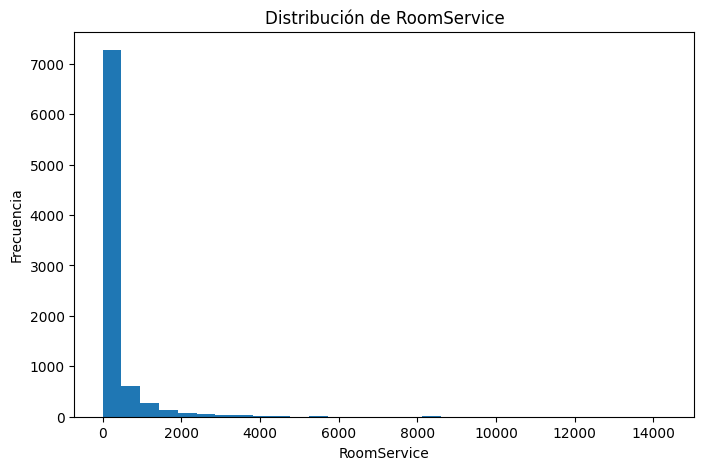

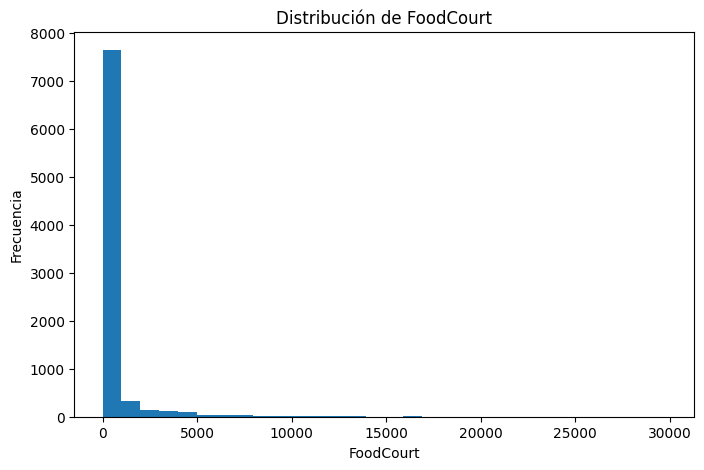

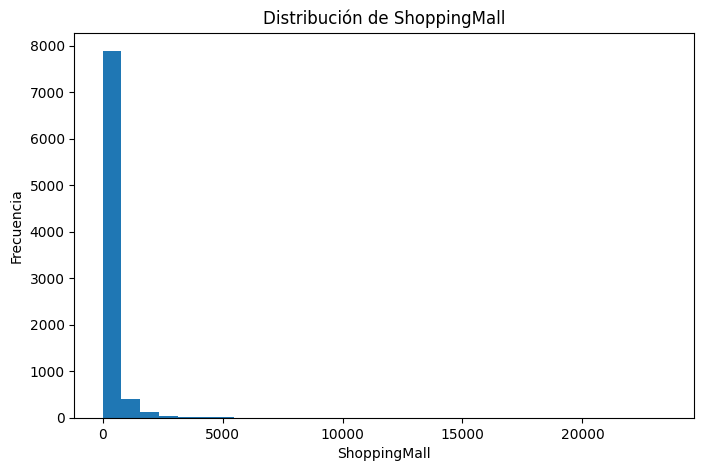

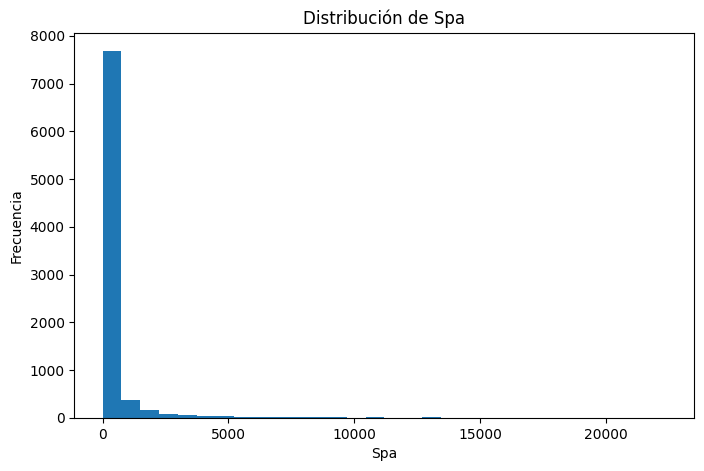

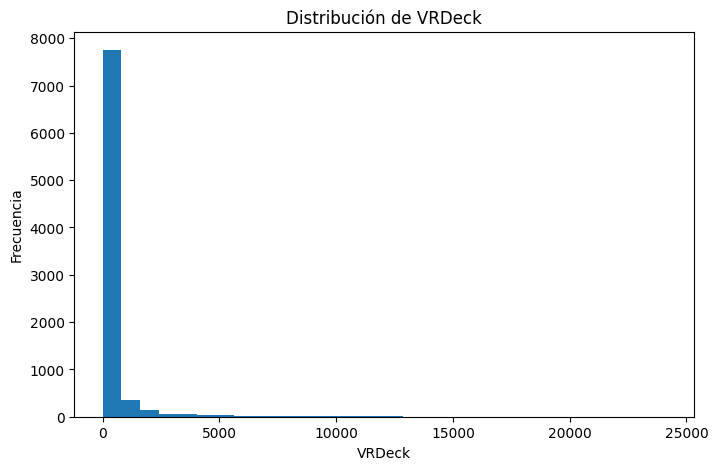

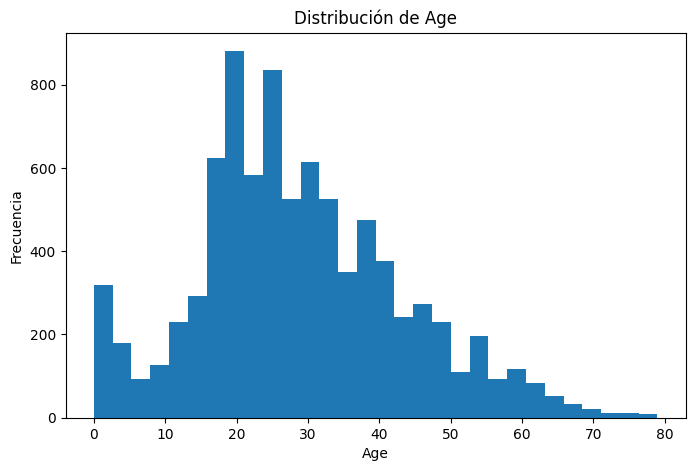

---------- Skewness ---------
RoomService      6.333014
FoodCourt        7.102228
ShoppingMall    12.627562
Spa              7.636020
VRDeck           7.819732
Age              0.419097
dtype: float64
---------- Outliers ---------
RoomService: 1861 outliers
FoodCourt: 1823 outliers
ShoppingMall: 1829 outliers
Spa: 1788 outliers
VRDeck: 1809 outliers
Age: 77 outliers
---------- Cardinalidad ---------
CryoSleep
False    0.641694
True     0.358306
Name: proportion, dtype: float64
VIP
False    0.976561
True     0.023439
Name: proportion, dtype: float64
HomePlanet
Earth     0.541922
Europa    0.250942
Mars      0.207136
Name: proportion, dtype: float64
Destination
TRAPPIST-1e      0.694983
55 Cancri e      0.211491
PSO J318.5-22    0.093526
Name: proportion, dtype: float64
Cabin_Deck
F    0.328938
G    0.301271
E    0.103132
B    0.091712
C    0.087944
D    0.056275
A    0.030139
T    0.000589
Name: proportion, dtype: float64
Cabin_Num
82      0.003296
86      0.002590
19      0.002590
176 

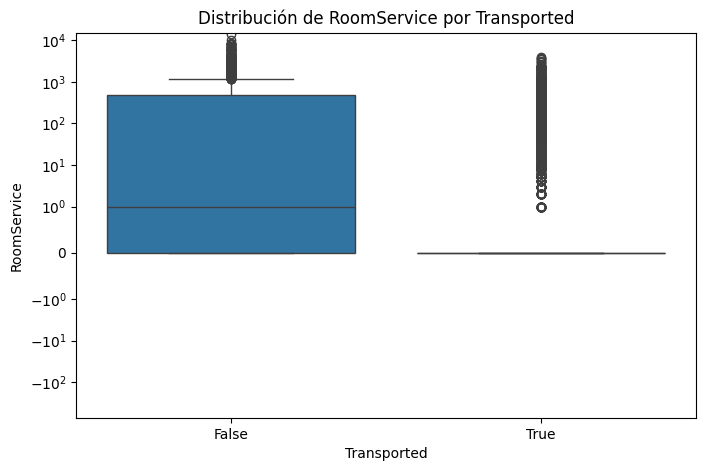

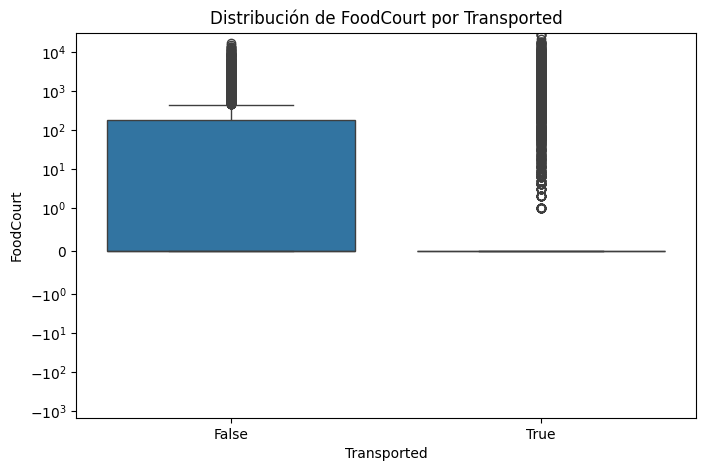

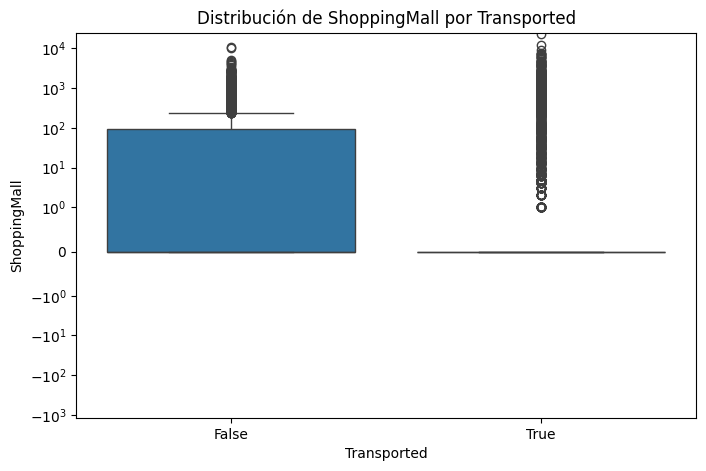

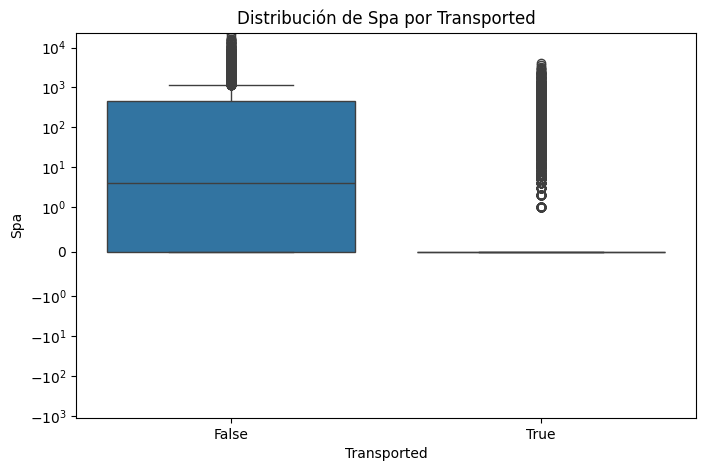

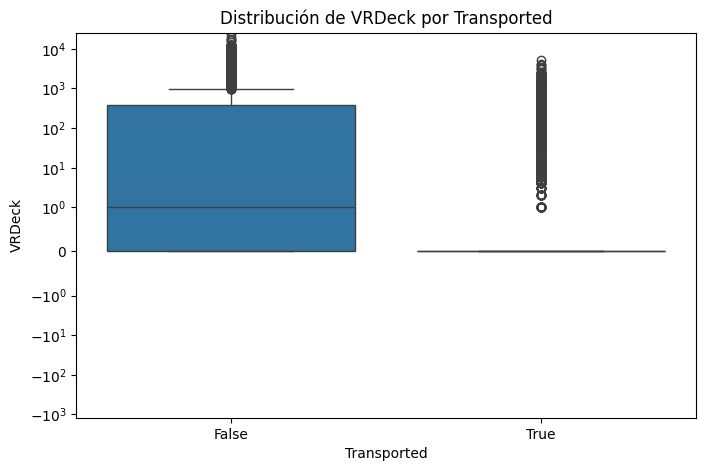


--- RoomService ---
              count        mean         std  min  25%   50%    75%      max
Transported                                                                
False        3569.0  448.336229  922.314810  0.0  0.0  17.0  593.0  14327.0
True         1759.0  150.920978  410.463092  0.0  0.0   0.0   59.0   3992.0

--- FoodCourt ---
              count         mean          std  min  25%   50%      75%  \
Transported                                                              
False        3576.0   442.368009  1287.071661  0.0  0.0   3.0   287.25   
True         1753.0  1265.083856  2823.836591  0.0  0.0  39.0  1065.00   

                 max  
Transported           
False        16856.0  
True         29813.0  

--- ShoppingMall ---
              count       mean          std  min  25%  50%    75%      max
Transported                                                               
False        3578.0  192.31526   486.931679  0.0  0.0  2.0  155.0  10705.0
True         1757.0 

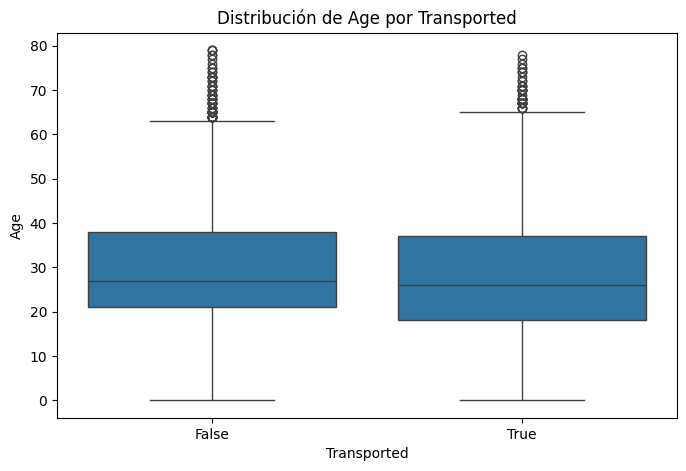

In [ ]:
porcentaje_faltantes = (df_train.isna().sum() / len(df_train)) * 100
print(f"Porcentaje de datos faltantes: \n {porcentaje_faltantes}")


numericas = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Age"]


print("---------- Histogramas ---------")
for col in numericas:
    plt.figure(figsize=(8, 5))
    plt.hist(df_train[col].dropna(), bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

print("---------- Skewness ---------")
print(df_train[numericas].skew())

print("---------- Outliers ---------")
for col in numericas:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_train[
        (df_train[col] < limite_inferior) |
        (df_train[col] > limite_superior)
    ]

    print(f'{col}: {len(outliers)} outliers')

print("---------- Cardinalidad ---------")

df_train[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df_train['Cabin'].str.split('/', expand=True)

print(df_train['CryoSleep'].value_counts(normalize=True))
print(df_train['VIP'].value_counts(normalize=True))
print(df_train['HomePlanet'].value_counts(normalize=True))
print(df_train['Destination'].value_counts(normalize=True))
print(df_train['Cabin_Deck'].value_counts(normalize=True))
print(df_train['Cabin_Num'].value_counts(normalize=True))
print(df_train['Cabin_Side'].value_counts(normalize=True))

print("---------- Crosstabs ---------")

categoricas = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Cabin_Deck", "Cabin_Side"]

for col in categoricas:
    print(pd.crosstab(df_train[col], df_train['Transported'], normalize='index'))

print("---------- Boxplots ---------")

numericas = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for col in numericas:

    plt.figure(figsize=(8, 5))

    sns.boxplot(x='Transported', y=col, data=df_train)

    plt.yscale('symlog', linthresh=1)

    plt.title(f'Distribución de {col} por Transported')
    plt.show()

for col in ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]:
    print(f"\n--- {col} ---")
    print(
        df_train[df_train['CryoSleep'] == False]
        .groupby('Transported')[col]
        .describe()
    )

plt.figure(figsize=(8, 5))

sns.boxplot(x='Transported', y="Age", data=df_train)

plt.title(f'Distribución de Age por Transported')
plt.show()





Primero se analizó la cantidad de valores faltantes por columna para conocer la calidad inicial de los datos y determinar si existían variables con un problema importante de missing values. Se encontró que los porcentajes son bastante uniformes, aproximadamente entre 2.1% y 2.5%, por lo que no existe una columna con una proporción de faltantes especialmente elevada.

Posteriormente se analizaron las variables numéricas mediante histogramas y skewness para conocer la forma de sus distribuciones. Las cinco variables de gasto presentan un sesgo positivo muy elevado, mientras que Age tiene una distribución mucho más cercana a la normalidad. Se utilizó el método de Tukey/IQR para identificar posibles outliers y se encontró una gran cantidad en las variables de gasto. Sin embargo, no se decidió eliminarlos ya que los valores extremos pueden representar gastos reales de los pasajeros y, por lo tanto, contener información predictiva.

Para las variables categoricas, se revisó su cardinalidad y distribución para conocer cuántas categorías existen y detectar posibles problemas de desbalance. La mayoría presenta una cardinalidad baja y manejable, mientras que Cabin_Num tiene una cardinalidad mucho mayor. VIP destaca como el único caso de desbalance extremo, ya que aproximadamente el 97.7% de los pasajeros no son VIP. También se descompuso Cabin en Cabin_Deck, Cabin_Num y Cabin_Side, ya que la variable original contiene tres componentes que pueden representar información diferente. Cabin_Deck y Cabin_Side se tratarán como variables categóricas, mientras que Cabin_Num se conservará como numérica para evaluar posteriormente si aporta información predictiva.

Después se utilizaron crosstabs para comprobar si las variables categóricas presentaban alguna relación con Transported. Cryosleep mostró la diferencia más marcada, con 81.8% de pasajeros transportados cuando CryoSleep=True frente al 32.9% cuando es False. Homeplanet también mostró diferencias relevantes, especialmente entre Europa y Earth. Destination, Cabin_Deck y Cabin_Side presentaron asociaciones más moderadas, por lo que su utilidad predictiva queda pendiente de confirmarse durante el modelado.

Finalmente se utilizaron boxplots para comparar las variables numéricas con Transported. Age no mostró una relación aparente, ya que las medianas y rangos intercuartílicos fueron muy similares entre ambos grupos. En cambio, las variables de gasto mostraron diferencias claras. Para comprobar si estas diferencias eran simplemente consecuencia de CryoSleep, se repitió el análisis únicamente con pasajeros que tenian CryoSleep=False. Las diferencias persistieron, indicando que las variables de gasto contienen información adicional a CryoSleep. Además RoomService, Spa y VRDeck mostraron una relación inversa con transported, mientras que FoodCourt y ShoppingMall mostraron una relación positiva. La razón de esta dirección opuesta entre grupos queda como una hipótesis abierta para etapas posteriores.
Con este análisis se obtuvo una visión suficiente de la estructura, calidad y relaciones principales del dataset para comenzar la parte 3, manteniendo inicialmente las variables de gasto y las variables derivadas de Cabin. Las principales decisiones de transformación, tratamiento de faltantes y selección definitiva de variables se validarán posteriormente mediante el pipeline y desempeño del modelo.



## 3. Selección y descarte de variables

* Define qué variables incluirás en el pipeline y cuáles descartarás.
* Cada decisión debe estar justificada con evidencia del EDA anterior: porcentaje de faltantes, desbalance extremo, relación con el target, cardinalidad, o redundancia. No se acepta descartar o incluir variables sin argumento.
* Para variables con desbalance extremo, evalúa si binarizar (HasPool, HasCabin, etc.) preserva señales útiles antes de descartarlas.

**Variables a descartar**
1. PassengerId: se eliminará el identificador de cada pasajero debido a que es un indicador único y por lo mismo no aporta valor predictivo por si mismo. Sin embargo se extraerá el grupo del Id y medidas derivadas de él que si son útiles.
2. Name: Se eliminará por las mismas razones que PassengerId, es un indicador único que no aportará al modelo.
3. Cabin: Se eliminará debido a su altísima cardinalidad de 6560 valores, además de que previamente ya extrajimos sus componentes por lo que la columna original es redundante y puede ser descartada.
4. VIP: Tiene un desbalance extremo y ya es una variable binaria, el 97.7% en false, por lo que existe el riesgo de que le añada ruido al modelo. El crosstab no mostró diferencias significativas en el caso negativo; mientras que en el caso positivo, aunque si mostró una diferencia de 12 puntos, debido a que son tan pocos registros no es posible determinar que sea un patron real.

**Variables a incluir**
1. HomePlanet:
De acuerdo a los datos del crosstab existe una difernecia notable entre las categorias Earth 42.4% transportado, Europa 65.9%, Mars 52.3%. La cardinalidad es baja por lo que son de fácil codificación de 3 categorías además los faltantes son manejables (2%) y se puede hacer imputación con moda o categoría "Missing".

2. CryoSleep:
Es la variable con mayor poder discriminante de todo el dataset con 81.8% transportados cuando True vs 32.9% cuando False (49 puntos de diferencia). Se incluye directamente.

3. Cabin_Side:
Son solo 2 valores (P: 45.1% transportado, S: 55.5%), existe una diferencia moderada y hay suficientes muestras de ambos lados.

4. Destination:
También tiene una diferencia moderada en transportados de acuerdo a su destino. Por su cardinalidad baja no complejiza tanto el análisis, todas las categorías tienen suficientes muestras para generalizar.

5. Group, GroupSize y IsAlone: Group se extraerá del PassengerId para revisar de que grupo era parte cada persona, a su vez se calculará el tamaño de grupo en el que viaja cada pasajero y si este grupo es de una (1) persona se añadirá como verdadero en la columna binaria IsAlone que indica si viaja solo el pasajero.


**Variables a transformar**
1. Cabin Deck: El deck T tiene muy pocas muestras, para evitar que se aprenda una relacion erronea basada en 5 datos se agregará al deck D, donde esta cantidad pequeña no afectará significativamente el comportamiento del deck D completo.
2. Cabin num: Pasar de variable categórica a una numérica para no tratar con una cardinalidad muy alta, además de que dicho número podría ser un indicador de la ubicación física en la nave.
3. RoomService, FoodCourt, ShoppingMall, Spa, VRDeck: Todas las variables de gasto tienen un sesgo positivo muy alto, por lo que se reescalarán logarítmicamente para reducir dicho sesgo sin perder la información de los valores extremos. Adicionalmente, se sumarán todos los gastos en una variable continua llamada *TotalSpent*, la cual también será reescalada logarítmicamente, y se creará una variable binaria llamada *HasSpent* que indicará si el pasajero realizó algún gasto durante su estadía o no. Ambas variables convivirán, ya que capturan información distinta: *HasSpent* refleja el efecto de umbral (si gastó o no, relacionado con CryoSleep), mientras que *TotalSpent* conserva la magnitud del gasto.
4. Age: La variable age se mantendrá sin cambios, pero además se añadirá una columna para que cada persona menor a 15 años sea considerada como un niño para que el modelo capture ese efecto.


In [ ]:
df_train['Cabin_Deck'].value_counts()

,count
Cabin_Deck,
F,2794
G,2559
E,876
B,779
C,747
D,478
A,256
T,5


In [ ]:
# Extraer el grupo y si viaja solo
df_train["Group"] = df_train["PassengerId"].str.split("_").str[0]
df_train["GroupSize"] = df_train.groupby("Group")["Group"].transform("count")
df_train["IsAlone"] = (df_train["GroupSize"] == 1).astype(int)

#borrar las columnas determinadas
df_train.drop(columns=["PassengerId", "Name", "Cabin", "VIP"], inplace=True)

#sumar los gastos para crear la columna de gasto total y si ha gastado
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
df_train["TotalSpent"] = df_train[spend_cols].sum(axis=1, skipna=True)
df_train["HasSpent"] = (df_train["TotalSpent"] > 0).astype(int)

#añadir columna binaria para saber si el pasajero es un niño
df_train["IsChild"] = (df_train["Age"] < 15).astype(int)

In [ ]:
df_train.head()

,HomePlanet,CryoSleep,Destination,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_Deck,Cabin_Num,Cabin_Side,Group,GroupSize,IsAlone,TotalSpent,HasSpent,IsChild
0,Europa,False,TRAPPIST-1e,39.0,0.0,0.0,0.0,0.0,0.0,False,B,0,P,0001,1,1,0.0,0,0
1,Earth,False,TRAPPIST-1e,24.0,109.0,9.0,25.0,549.0,44.0,True,F,0,S,0002,1,1,736.0,1,0
2,Europa,False,TRAPPIST-1e,58.0,43.0,3576.0,0.0,6715.0,49.0,False,A,0,S,0003,2,0,10383.0,1,0
3,Europa,False,TRAPPIST-1e,33.0,0.0,1283.0,371.0,3329.0,193.0,False,A,0,S,0003,2,0,5176.0,1,0
4,Earth,False,TRAPPIST-1e,16.0,303.0,70.0,151.0,565.0,2.0,True,F,1,S,0004,1,1,1091.0,1,0


In [ ]:
print(df_train.shape)
print(df_train[["TotalSpent", "HasSpent", "IsChild"]].sample())

(8693, 19)
      TotalSpent  HasSpent  IsChild
8669      8803.0         1        0


## 4. Manejo de faltantes

* Aplica la estrategia de imputación correspondiente según la clasificación del paso 2.
* Justifica la elección de estrategia para cada variable. No uses la misma estrategia para todo sin argumentar.


In [ ]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# CryoSleep (categórica, 2.5% faltante): Faltante informativo
gasto_conocido = df_train[spend_cols].sum(axis=1, skipna=True) > 0
mask_cryo_missing = df_train["CryoSleep"].isna()
df_train.loc[mask_cryo_missing & gasto_conocido, "CryoSleep"] = False

# Lo que sobra sin gasto registrado y sin señal recuperable es faltante real
df_train["CryoSleep"] = df_train["CryoSleep"].fillna(df_train["CryoSleep"].mode()[0]).astype(bool)

# Variables de gasto: Faltante informativo parcial
# Si CryoSleep == True, el faltante en gasto es 0
for col in spend_cols:
    mask = df_train[col].isna() & (df_train["CryoSleep"] == True)
    df_train.loc[mask, col] = 0

# Faltante real: no se sabe cuanto gastó la persona, se usa mediana
for col in spend_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

# Age (2% faltante, distribución casi normal y pocos outliers): Faltante real sin nada que nos ayude a recuperarlo.
# Usar mediana por su robustez
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

homeplanet_por_grupo = (
    df_train.dropna(subset=["HomePlanet"])
    .groupby("Group")["HomePlanet"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)
mask_hp_na = df_train["HomePlanet"].isna()
df_train.loc[mask_hp_na, "HomePlanet"] = df_train.loc[mask_hp_na, "Group"].map(homeplanet_por_grupo)


# HomePlanet, Destination, Cabin_Side (nominales, baja cardinalidad): Faltante real sin relación con otra columna para recuperarla
# Usar moda
for col in ["HomePlanet", "Destination", "Cabin_Side"]:
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

# Cabin_Deck / Cabin_Num
# Se fusiona el deck T dentro de D.
df_train["Cabin_Deck"] = df_train["Cabin_Deck"].replace("T", "D")
df_train["Cabin_Deck"] = df_train["Cabin_Deck"].fillna(df_train["Cabin_Deck"].mode()[0])

#Cabin_Num
df_train["Cabin_Num"] = pd.to_numeric(df_train["Cabin_Num"], errors="coerce")
mediana_por_deck = df_train.groupby("Cabin_Deck")["Cabin_Num"].transform("median")
df_train["Cabin_Num"] = df_train["Cabin_Num"].fillna(mediana_por_deck)
df_train["Cabin_Num"] = df_train["Cabin_Num"].fillna(df_train["Cabin_Num"].median())

#Recalcular variables otra vez
df_train["TotalSpent"] = df_train[spend_cols].sum(axis=1)
df_train["HasSpent"] = (df_train["TotalSpent"] >0).astype(int)
df_train["IsChild"] = (df_train["Age"] < 15).astype(int)

df_train.drop(columns="Group", inplace=True)

print(df_train.isna().sum())

/tmp/ipykernel_1527/702910672.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train["CryoSleep"] = df_train["CryoSleep"].fillna(df_train["CryoSleep"].mode()[0]).astype(bool)


HomePlanet      0
CryoSleep       0
Destination     0
Age             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Cabin_Deck      0
Cabin_Num       0
Cabin_Side      0
GroupSize       0
IsAlone         0
TotalSpent      0
HasSpent        0
IsChild         0
dtype: int64


**CryoSleep**:
Se identificó como faltante parcialmente informativo ya que un pasajero en CryoSleep no puede realizar gastos en ningún servicio, por lo que si un registro con CryoSleep faltante presenta gasto mayor a 0 en alguna de las variables de gasto entonces podedmos inferir con alta confianza que CryoSleep = False. Los faltantes restantes, sin gasto registrado ni señal recuperable, se consideran faltante real y se imputan con la moda, dado que ya representan menos del 1% del total tras aplicar la regla anterior.

**RoomService, FoodCourt, ShoppingMall, Spa, VRDeck**:
Al igual que CryoSleep, si CryoSleep = True, el faltante corresponde a un gasto de 0, no a un valor desconocido ya que de la misma manera los pasajeros en CryoSleep no pueden realizar gastos. Los faltantes restantes con CryoSleep = False sí son faltante real, ya que no hay forma de inferir cuánto gastó la persona, dado el sesgo positivo extremo y la gran cantidad de outliers detectados en el EDA, se imputó con la mediana en lugar de la media, por ser más robusta a esos valores extremos.

**Age**:
Faltante real sin relación recuperable con otras variables, al tener una distribución cercana a la normal y bajo porcentaje de faltantes del 2% considerado bajo, se imputa con la mediana.

**HomePlanet, Destination, Cabin_Side**:
Faltante real: a diferencia de CryoSleep y las variables de gasto, no se encontró en el EDA una relación lógica con otras columnas que permita inferir el valor faltante. Por su baja cardinalidad y bajo porcentaje de faltantes de aprox 2%, se imputan con la moda, evitando introducir una categoría de faltante que el modelo tendría que aprender a partir de muy pocos casos.

**Cabin_Deck y Cabin_Num**:
Antes de imputar, se completó la transformación pendiente del paso 3, el deck T que solo cuenta con 5 registros se fusionó con el deck D. Cabin_Deck se imputó con moda por las mismas razones que las demás categóricas nominales. Cabin Num se imputa por deck porque el propio valor de CabinNum depende de en qué deck está la cabina, así que una mediana global asignaría posiciones poco realistas.

TotalSpent, HasSpent y IsChild se habían calculado en el paso 3 antes de tratar los faltantes, lo cual implicaba algunas imputaciones tales como NaN tratado como 0 en la suma, y Age faltante evaluado como "no niño" así que recalculamos estas variables después de completar la imputación para tener consistencia.

## 5. Codificación de variables categóricas

* Codifica las variables categóricas según el tipo de variable (nominal/ordinal).
* Justifica tu estrategia de codificación.
Verifica que no queden columnas de tipo object después de la codificación.

In [ ]:
# Variables binarias: mapeo directo
df_train["CryoSleep"] = df_train["CryoSleep"].astype(int)
df_train["Cabin_Side"] = df_train["Cabin_Side"].map({"P": 0, "S": 1})
df_train["Transported"] = df_train["Transported"].astype(int)

# Variables nominales con one-hot encoding para evitar una relacion de orden falsa, además de que la cardinalidad de ellos es pequeña
df_train = pd.get_dummies(
    df_train,
    columns=["HomePlanet", "Destination", "Cabin_Deck"],
    drop_first=True
)

# normalizar get_dummies a int
dummy_cols = df_train.select_dtypes(include="bool").columns
df_train[dummy_cols] = df_train[dummy_cols].astype(int)

# Verificación
print(df_train.dtypes)
print("Columnas object:", df_train.select_dtypes(include="object").columns.tolist())

CryoSleep                      int64
Age                          float64
RoomService                  float64
FoodCourt                    float64
ShoppingMall                 float64
Spa                          float64
VRDeck                       float64
Transported                    int64
Cabin_Num                    float64
Cabin_Side                     int64
GroupSize                      int64
IsAlone                        int64
TotalSpent                   float64
HasSpent                       int64
IsChild                        int64
HomePlanet_Europa              int64
HomePlanet_Mars                int64
Destination_PSO J318.5-22      int64
Destination_TRAPPIST-1e        int64
Cabin_Deck_B                   int64
Cabin_Deck_C                   int64
Cabin_Deck_D                   int64
Cabin_Deck_E                   int64
Cabin_Deck_F                   int64
Cabin_Deck_G                   int64
dtype: object
Columnas object: []


**CryoSleep, Cabin_Side, Transported**
Se codificaron con mapeo binario directo 0/1 ya que al tener únicamente 2 categorías, no aplica la distinción nominal/ordinal.

**HomePlanet, Destination, Cabin_Deck**
Se codificaron con one-hot encoding ya que ninguna de las tres tiene un orden natural entre sus categorías no hay un ranking entre planetas, destinos o decks, por lo que un label encoding introduciría una relación de orden falsa que el modelo podría interpretar erróneamente como significativa. La cardinalidad de las tres es baja por lo que el one-hot no incrementa de forma importante la dimensionalidad del dataset. Se usó drop_first=True en las tres para evitar colinealidad perfecta entre las columnas dummy.


## 6. Transformación de variables numéricas

* Revisa si alguna variable numérica tiene sesgo significativo.
* Aplica una transformación justificada donde corresponda.
* Muestra la distribución antes y después para cada variable transformada.

Skewness antes de transformar:
ShoppingMall    12.763842
VRDeck           7.904554
Spa              7.716450
FoodCourt        7.177515
RoomService      6.397766
TotalSpent       4.417588
Cabin_Num        0.677708
Age              0.431102
dtype: float64


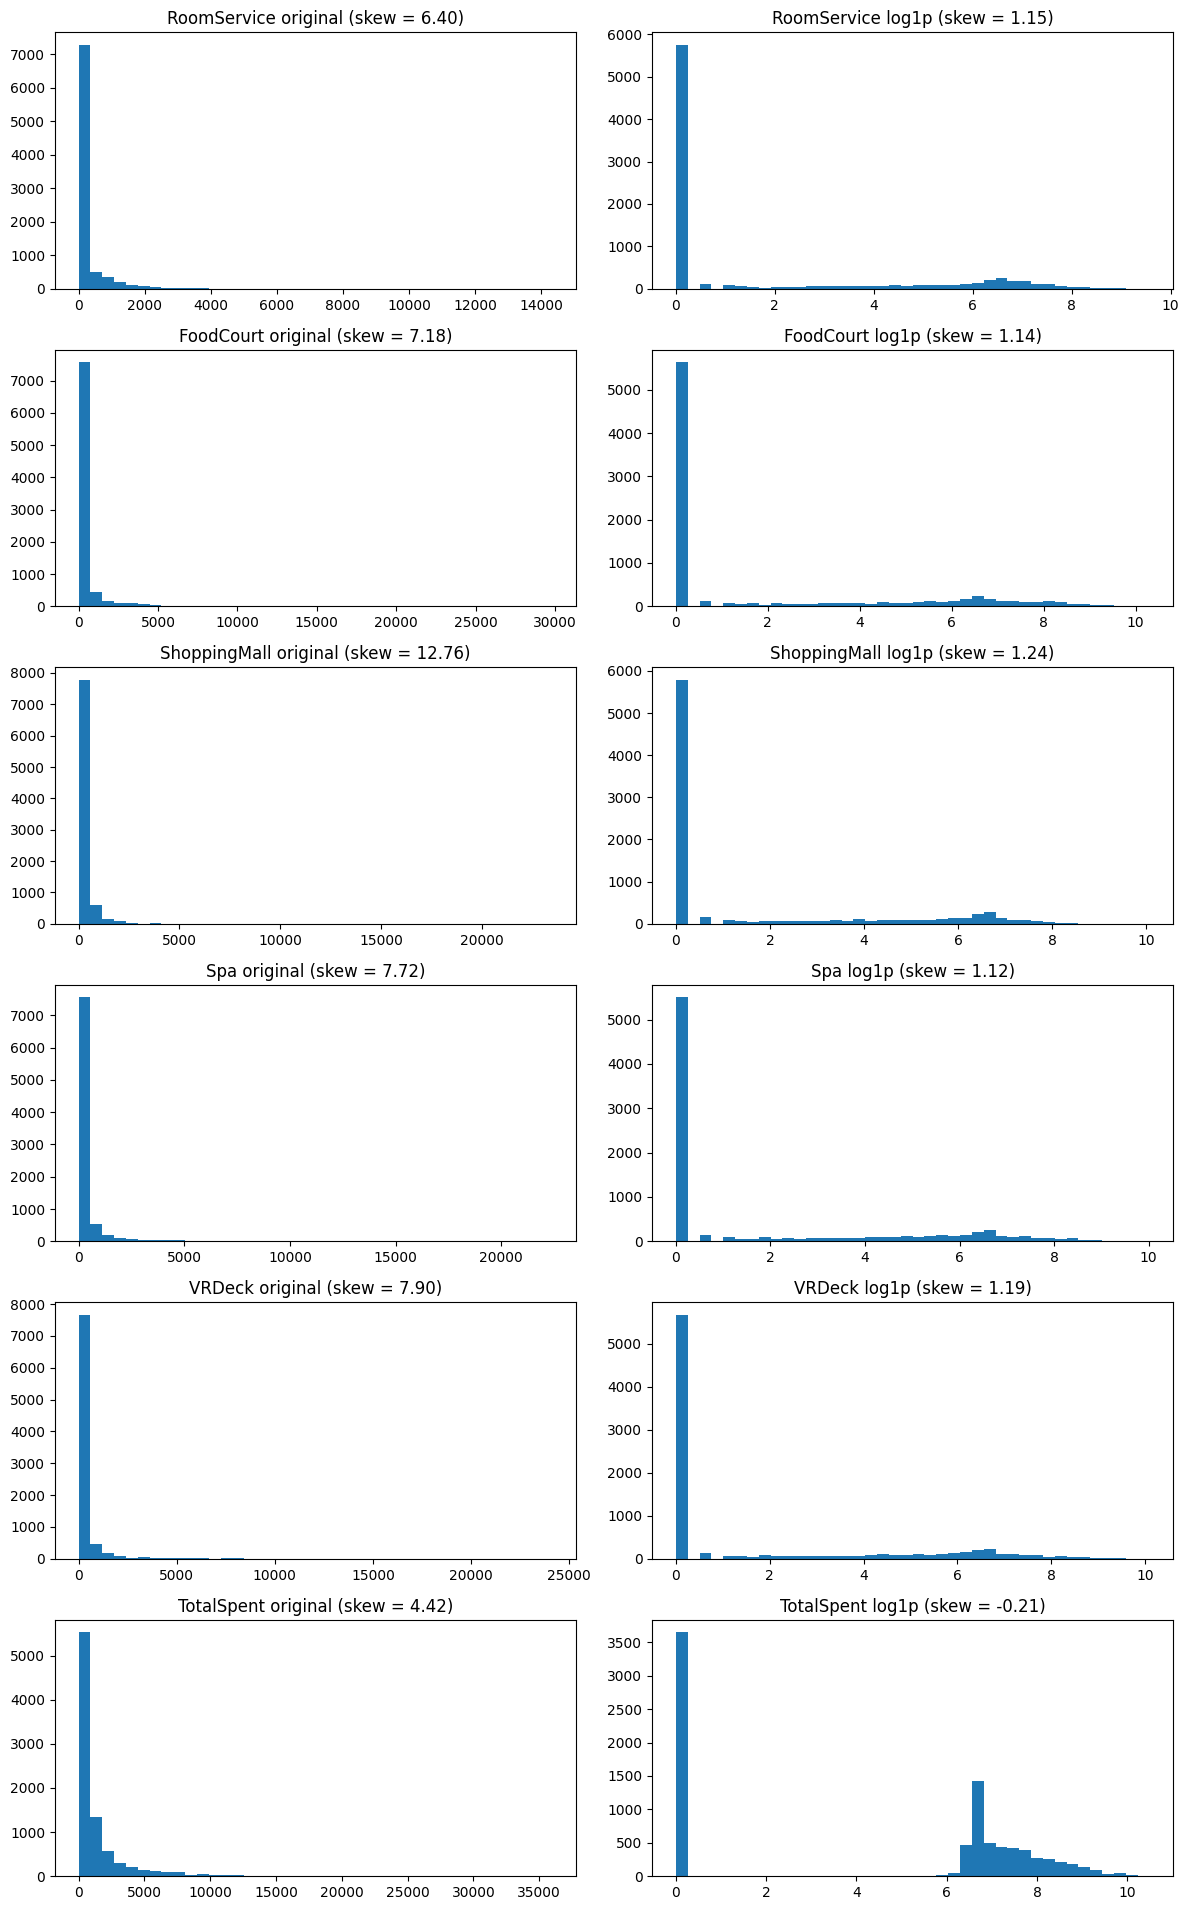

                      skew  outliers_iqr
RoomService_log   1.149866             1
FoodCourt_log     1.143177             0
ShoppingMall_log  1.238498            72
Spa_log           1.122324             1
VRDeck_log        1.193417            23
TotalSpent_log   -0.212435             0
Age               0.431102           162
Cabin_Num         0.677708             0


In [ ]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
log_cols = spend_cols + ["TotalSpent"]
continuas = log_cols + ["Age", "Cabin_Num"]

print("Skewness antes de transformar:")
print(df_train[continuas].skew().sort_values(ascending=False))


fig, axes = plt.subplots(len(log_cols), 2, figsize=(12, 3.2 * len(log_cols)))

for i, col in enumerate(log_cols):
    original = df_train[col]
    transformada = np.log1p(original)

    axes[i, 0].hist(original, bins=40)
    axes[i, 0].set_title(f"{col} original (skew = {original.skew():.2f})")

    axes[i, 1].hist(transformada, bins=40)
    axes[i, 1].set_title(f"{col} log1p (skew = {transformada.skew():.2f})")

plt.tight_layout()
plt.show()


df_train[[f"{col}_log" for col in log_cols]] = np.log1p(df_train[log_cols])
df_train.drop(columns=log_cols, inplace=True)

continuas = [f"{col}_log" for col in log_cols] + ["Age", "Cabin_Num"]

def contar_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum())

resumen = pd.DataFrame({
    "skew": df_train[continuas].skew(),
    "outliers_iqr": [contar_outliers(df_train[c]) for c in continuas]
})
print(resumen)

Primero se ve el sesgo únicamente de las variables continuas, porque en las binarias y en las columnas dummy generadas en el paso anterior el skew no describe la forma de una distribución sino el desbalance.

Las cinco variables de gasto junto con TotalSpent presentan un sesgo positivo de entre 6.3 y 12.6, estos vienen por la gran cantidad de 0s en totalspent por la gente en **Cryo**.
Se usa una transformación logarítmica con log1p en lugar del logaritmo natural.
log1p mapea el 0, conserva el orden de los gastos y comprime la cola sin eliminar los valores extremos.

Al comparar los histogramas antes y después se observa que el sesgo baja de valores de 6-12 hasta magnitudes cercanas a 1, y que la cantidad de outliers detectados por Tukey disminuye de forma importante.

Age no se transformó tiene un sesgo de 0.419 este se encuentra dentro del rango de |0.5| que se considera simétrico, como se veia en el histograma. Cabin_Num tampoco se transformó,  su sesgo es moderado y se trata de su posición dentro del deck y no de una magnitud, por lo que comprimir logarítmicamente los números altos no funcionaría.

## 7. Escalado

* Aplica el escalador que corresponda según la presencia de outliers.
* Justifica la elección.


In [ ]:
from sklearn.preprocessing import RobustScaler

y = df_train["Transported"]
X = df_train.drop(columns="Transported")

binarias = [c for c in X.columns if c not in continuas]
print("Binarias:", binarias)
print("Valores distintos en binarias:", sorted(pd.unique(X[binarias].values.ravel())))

antes = X[continuas].describe().T[["mean", "50%", "std", "min", "max"]]

scaler = RobustScaler()
X[continuas] = scaler.fit_transform(X[continuas])

despues = X[continuas].describe().T[["mean", "50%", "std", "min", "max"]]

print(pd.DataFrame({"centro": scaler.center_, "escala": scaler.scale_}, index=continuas))
print("\nAntes:\n", antes)
print("\nDespués:\n", despues)

Binarias: ['CryoSleep', 'Cabin_Side', 'GroupSize', 'IsAlone', 'HasSpent', 'IsChild', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Cabin_Deck_B', 'Cabin_Deck_C', 'Cabin_Deck_D', 'Cabin_Deck_E', 'Cabin_Deck_F', 'Cabin_Deck_G']
Valores distintos en binarias: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
                      centro      escala
RoomService_log     0.000000    3.737670
FoodCourt_log       0.000000    4.127134
ShoppingMall_log    0.000000    3.135494
Spa_log             0.000000    3.988984
VRDeck_log          0.000000    3.713572
TotalSpent_log      6.575076    7.273786
Age                27.000000   17.000000
Cabin_Num         448.000000  810.000000

Antes:
                         mean         50%         std  min          max
RoomService_log     1.735295    0.000000    2.719285  0.0     9.569971
FoodCourt_log       1.906543    0.000000    2.932951  

Se escalaron únicamente las variables continuas, las variables de gasto transformadas, Age y Cabin_Num. Las variables binarias y dummy no se escalaron porque ya se encuentran entre 0 y 1. Transported tampoco porque es la variable objetivo.

Se utilizó RobustScaler porque todavía existen outliers después de la transformación, principalmente en Age. Este scaler utiliza la mediana y el rango de cuartiles, por lo que los valores en los. extremos afectan menos el resultado.

También se descartó MinMaxScaler porque utiliza los valores mínimos y máximos, por lo que los outliers podrían comprimir demasiado el resto de los datos.

El scaler se ajustó únicamente con train y después se aplicará a test con transform para evitar usar información del conjunto de prueba durante el entrenamiento.

## 8. Verificación final

* Confirma que no quedan nulos en el conjunto procesado.
* Confirma que no quedan columnas de tipo object.
* Reporta el shape final del dataset procesado.
* Genera una tabla resumen de todas las decisiones tomadas: variable, tipo, tratamiento aplicado, justificación.
* Genera una breve conclusión con el análisis y hallazgos del conjunto de datos seleccionado.

In [ ]:
# 1. Confirmar que no quedan nulos
nulos_X = X.isna().sum()
nulos_y = y.isna().sum()
print("Nulos en X:", nulos_X[nulos_X > 0] if nulos_X.sum() > 0 else "No quedan valores nulos en X.")
print("Nulos en y:", nulos_y if nulos_y > 0 else "No quedan valores nulos en y.")

# 2. Confirmar que no quedan columnas tipo object
cols_object = X.select_dtypes(include="object").columns.tolist()
print("\nColumnas tipo object:", cols_object if cols_object else "Ninguna, todas las columnas son numéricas.")

# 3. Shape final
print("\nShape final de X:", X.shape)
print("Shape final de y:", y.shape)

Nulos en X: No quedan valores nulos en X.
Nulos en y: No quedan valores nulos en y.

Columnas tipo object: Ninguna, todas las columnas son numéricas.

Shape final de X: (8693, 24)
Shape final de y: (8693,)


## Tabla de resumen

| Variable | Tipo | Tratamiento aplicado | Justificación |
|---|---|---|---|
| PassengerId | Identificador | Eliminada | Identificador único por fila, sin valor predictivo |
| Name | Texto | Eliminada | Identificador único (con repetidos/NaN), sin valor predictivo |
| Cabin | Categórica (compuesta) | Eliminada (descompuesta en Deck/Num/Side) | Cardinalidad altísima (6560 valores); redundante tras extraer sus componentes |
| VIP | Binaria | Eliminada | Desbalance extremo (97.7% False); diferencia con el target poco concluyente por bajo n |
| HomePlanet | Nominal | Imputación por moda + One-hot encoding (drop_first) | Sin orden natural entre categorías; baja cardinalidad; diferencia notable con el target (Earth 42.4%, Europa 65.9%, Mars 52.3%) |
| Destination | Nominal | Imputación por moda + One-hot encoding (drop_first) | Sin orden natural; baja cardinalidad; diferencia moderada con el target |
| Cabin_Deck | Nominal | Deck T fusionado con D + imputación por moda + One-hot encoding (drop_first) | Deck T con solo 5 registros (riesgo de aprender relación espuria); sin orden natural |
| Cabin_Side | Binaria | Imputación por moda + mapeo 0/1 (P=0, S=1) | Solo 2 categorías; diferencia moderada con el target (P 45.1% vs S 55.5%) |
| Cabin_Num | Numérica | Conversión a numérica + imputación por mediana (sin transformación ni escalado log) | Representa posición física en la nave, no una magnitud; sesgo moderado no justifica log; cardinalidad alta pero mediana no se ve afectada por ella |
| CryoSleep | Binaria | Imputación condicional (False si hay gasto > 0, moda en el resto) + mapeo a 0/1 | Faltante parcialmente informativo (en CryoSleep no se puede gastar); mayor poder discriminante del dataset (81.8% vs 32.9% transportados) |
| RoomService, FoodCourt, ShoppingMall, Spa, VRDeck | Numérica | Imputación condicional (0 si CryoSleep=True, mediana en el resto) + transformación log1p + RobustScaler | Faltante parcialmente informativo; sesgo positivo extremo (6.3–12.6) con muchos outliers (Tukey) |
| TotalSpent | Numérica (derivada) | Suma de gastos, recalculada tras imputación + log1p + RobustScaler | Captura el gasto total como señal agregada; mismo sesgo extremo que las variables de gasto individuales |
| HasSpent | Binaria (derivada) | Recalculada tras imputación (1 si TotalSpent > 0) | Señal simple de si el pasajero consumió algún servicio, complementa TotalSpent |
| IsChild | Binaria (derivada) | Recalculada tras imputación (1 si Age < 15) | Captura un posible efecto no lineal de la edad que Age por sí sola no refleja |
| Age | Numérica | Imputación por mediana (sin transformación log) | Faltante real sin relación recuperable; distribución casi normal (skew 0.419, dentro de rango simétrico) |
| Transported | Binaria (target) | Mapeo a 0/1 | Variable objetivo del problema de clasificación binaria |



## Conclusión
El dataset quedó completamente numérico, sin valores nulos y listo para modelar, con X conteniendo las variables predictoras escaladas y transformadas, y y la variable objetivo Transported. El hallazgo más relevante del análisis fue que CryoSleep es, por mucho, la variable con mayor poder discriminante (49 puntos de diferencia en tasa de transportados entre True y False), seguida por HomePlanet y las variables de gasto, cuya relación con el target solo se hizo evidente al segmentar por CryoSleep. El patrón de grupo detectado en PassengerId también resultó útil más allá de HomePlanet: permitió derivar GroupSize e IsAlone como variables predictoras adicionales. En contraste, Age no mostró relación aparente con la variable objetivo de forma agregada. El manejo cuidadoso de los faltantes informativos (especialmente en CryoSleep, los gastos y HomePlanet por consenso de grupo) permitió recuperar señal que se habría perdido con una imputación genérica, y las transformaciones aplicadas (log1p + RobustScaler) atienden directamente el sesgo extremo y los outliers detectados en el EDA.

---
# Segundo avance
---

## 1. Carga de datos preprocesados

- Carga el dataset procesado que generaste en el primer avance y reporta el shape.
- Si tu entrega anterior tenía errores de preparación que te impiden arrancar, corrígelos aquí y documenta qué corregiste y por qué estaba mal.

*Nota de fusión: en las entregas por separado, el dataset procesado se exportaba a `train_processed.csv` y se volvía a cargar en el Segundo Avance mediante `files.upload()`. Al combinar ambos avances en un solo notebook, el dataset ya procesado (`df_train`) se reutiliza directamente en memoria, por lo que solo se carga una vez.*

In [ ]:
# Reutilizamos en memoria el dataset ya procesado en la Parte 1 (Primer Avance),
# sin necesidad de exportarlo a CSV y volver a cargarlo.
df = df_train
print(f"Shape del dataset procesado: {df.shape}")
df.head()

Shape del dataset procesado: (8693, 25)


,CryoSleep,Age,Transported,Cabin_Num,Cabin_Side,GroupSize,IsAlone,HasSpent,IsChild,HomePlanet_Europa,...,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,RoomService_log,FoodCourt_log,ShoppingMall_log,Spa_log,VRDeck_log,TotalSpent_log
0,0,39.0,0,0.0,0,1,1,0,0,1,...,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,24.0,1,0.0,1,1,1,1,0,0,...,0,0,1,0,4.700480,2.302585,3.258097,6.309918,3.806662,6.602588
2,0,58.0,0,0.0,1,2,0,1,0,1,...,0,0,0,0,3.784190,8.182280,0.000000,8.812248,3.912023,9.248021
3,0,33.0,0,0.0,1,2,0,1,0,1,...,0,0,0,0,0.000000,7.157735,5.918894,8.110728,5.267858,8.551981
4,0,16.0,1,1.0,1,1,1,1,0,0,...,0,0,1,0,5.717028,4.262680,5.023881,6.338594,1.098612,6.995766


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Transported")
y = df["Transported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (6954, 24) Test: (1739, 24)


Se cargó el dataset ya procesado en el primer avance, correspondiente a train.csv, con un total de 8693 filas y 25 columnas, incluyendo la variable objetivo `Transported`. El dataset se encuentra completamente numérico, sin valores nulos y con todas las transformaciones aplicadas previamente (codificación categórica, transformación logarítmica de variables de gasto y escalado con RobustScaler), por lo que queda listo para el entrenamiento de modelos.

Se corrigió un error de preparación identificado en la retroalimentación del avance anterior: los datos se cargaban mediante kagglehub, apuntando a una ruta absoluta del caché local de Kaggle. Esto impedía ejecutar el notebook en otra máquina sin conexión a internet ni una cuenta de Kaggle configurada, ya que la descarga dependía de un servicio externo y de una ruta específica del entorno original. Para corregirlo, se exportó el dataset ya procesado a un archivo train_processed.csv y se carga aquí desde una ruta relativa dentro del proyecto, eliminando por completo la dependencia de kagglehub y garantizando que el notebook pueda reproducirse en cualquier entorno.

## 2. Selección de métricas

- Define qué métricas usarás para comparar modelos y justifica tu elección con base en las características del dataset.
- Calcula el baseline: El rendimiento mínimo que cualquier modelo debe superar. Reporta qué métrica tiene el baseline y cuánto vale.

In [ ]:
# Verificando el balance de clases
print(df["Transported"].value_counts(normalize=True))

Transported
1    0.503624
0    0.496376
Name: proportion, dtype: float64


Se verificó el balance de clases de la variable objetivo, obteniendo una distribución practicamente equilibrada. Esto indica que no hay riesgo de que accuracy resulte engañoso por una clase dominante, y que no existiría una razón basada en datos para priorizar precision sobre recall o viceversa.

Sin embargo, el entendimiento del negocio que el equipo realizó para el módulo RI, establece una importancia entre los tipos de error: un falso negativo (no identificar un pasajero que si fue transportado) implica que esa persona nunca será incluida en las labores de búsqueda y rescate, lo cual tiene una consecuencia humana grave e irreversible. Un falso positivo (marcar como transportada a una persona que no lo fue), en cambio, unicamente implica destinar recursos a una búsqueda que no encuentra resultado.

Por lo tanto, las métricas seleccionadas son:
- Recall: Métrica principal de desición entre modelos,ya que mide directamente la capacidad del moddelo para no dejar pasajeros transportados sin detectar, que es el error que el negocio busca minimizar.
- F1-score: Métrica secundaria, para evitar que el modelo maximice recall de forma trivial (prediciendo siempre transportado) a costa de una precision inaceptablemente baja.
- Acurracy: métrica de referencia general, interpretable dado que las clases estan balanceadas.
- Precision y Specificity: Se reportan para caracterizar completamente el comportamiento del modelo, aunque no son el criterio de decision.
- Matriz de confusión: se reporta en cada modelo para visualizar el trade-off entre falsos positivos y falsos negativos.



In [ ]:
from sklearn.metrics import (
    recall_score,
    f1_score,
    accuracy_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


## 3. Entrenamiento de modelos

- Entrena mínimo 2 modelos de distinta familia.
- Para cada modelo:
  - Instancia el modelo con los hiperparámetros que elijas y justifica por qué elegiste esos valores iniciales.
  - Entrena sobre los datos de train.
  - Genera predicciones sobre test.
  - Reporta las métricas de evaluación correspondientes.
  - Interpreta los resultados: ¿dónde falla el modelo?, ¿qué tipo de error comete más?, ¿qué implica eso en el contexto del problema?

#### Modelo A: Random forest clasifier

**Entrenaminto**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Definir el espacio de búsqueda (Parameter Grid)
param_grid = {
    'n_estimators': [100, 300, 500],       # Cantidad de árboles
    'max_depth': [8, 12, 15, None],        # Profundidad de cada árbol
    'min_samples_split': [5, 10, 20]       # Resistencia al sobreajuste
}

# 2. Instanciar el modelo base
rf_base = RandomForestClassifier(random_state=42)

# 3. Configurar GridSearchCV enfocado en la métrica principal (Recall)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='recall',      # El modelo ganador será el que tenga mejor Recall
    cv=5,                  # Validación cruzada de 5 particiones
    n_jobs=-1,             # Usa todos los núcleos del procesador
    verbose=2              # Muestra el progreso en la consola
)

# 4. Ejecutar la búsqueda con los datos de entrenamiento
print("Iniciando Grid Search. Esto evaluará 36 combinaciones x 5 pliegues = 180 ajustes...")
grid_search.fit(X_train, y_train)

# 5. Extraer y mostrar al ganador
print(f"\nMejores hiperparámetros encontrados para maximizar Recall:")
print(grid_search.best_params_)

# 6. Generar predicciones con el mejor modelo
best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)

Iniciando Grid Search. Esto evaluará 36 combinaciones x 5 pliegues = 180 ajustes...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Mejores hiperparámetros encontrados para maximizar Recall:
{'max_depth': 12, 'min_samples_split': 20, 'n_estimators': 500}


**Evaluación**

In [ ]:
def evaluar_spaceship_model(y_test, y_pred, modelo_nombre="Modelo"):
    print(f"--- Evaluación de: {modelo_nombre} ---")

    # 1. Calcular la Matriz de Confusión para extraer TN, FP, FN, TP
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # 2. Calcular las métricas directas
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    # 3. Calcular Specificity (Tasa de Verdaderos Negativos)
    specificity = tn / (tn + fp)

    # 4. Reporte alineado a tus prioridades
    print(f"Métrica Principal (Criterio de decisión):")
    print(f" * Recall:      {recall:.4f}")

    print(f"\nMétrica Secundaria (Filtro de calidad):")
    print(f" * F1-Score:    {f1:.4f}")

    print(f"\nMétricas de Referencia / Contexto:")
    print(f" * Accuracy:    {accuracy:.4f}")
    print(f" * Precision:   {precision:.4f}")
    print(f" * Specificity: {specificity:.4f}")

    # 5. Visualizar el trade-off con la Matriz de Confusión
    print("\nGenerando Matriz de Confusión...")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No transportado (0)", "Transportado (1)"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Matriz de Confusión - {modelo_nombre}")
    plt.show()


--- Evaluación de: Random Forest Base ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.8037

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.8069

Métricas de Referencia / Contexto:
 * Accuracy:    0.8062
 * Precision:   0.8101
 * Specificity: 0.8088

Generando Matriz de Confusión...


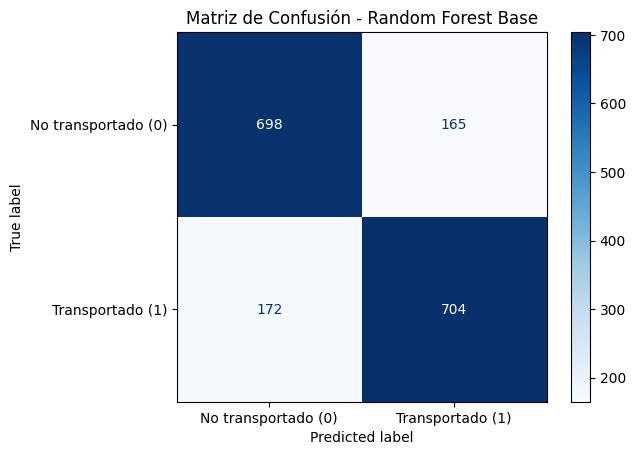

In [ ]:

# Ejecución
evaluar_spaceship_model(y_test, y_pred_best_rf, "Random Forest Base")

**Interpretación**.

El modelo, con los hiperparametros ajustados mediante grid evaluation, generó buenos resultados en general; fue acertado aproximadamente el 80% de las veces.

Sin embargo, al desglosar la matriz de confusión podemos observar que comete 172 errores de tipo 2 (falsos negativos) y 165 errores de tipo 1 (falsos positivos); por si mismo parece una medida balanceada, pero revela que el algoritmo se equivoca con mayor frecuencia asumiendo que los pasajeros están a salvo.

Esto se refleja directamente en las métricas: el Recall (80.69%) es la métrica más baja del reporte. El modelo está dejando escapar a casi el 20% de las personas que realmente sufrieron el accidente espaciotemporal.
En el escenario operativo de la compañía del Spaceship Titanic, cometer más Falsos Negativos que Falsos Positivos es el peor escenario posible para la gestión de la crisis.

El sistema asume que el pasajero está seguro a bordo y no lo reporta como desaparecido. La consecuencia directa es que no se destinarán recursos de búsqueda y rescate para esa persona, abandonándola a su suerte en la dimensión alternativa. Legal y éticamente, es una enorme falla para la corporación.

El modelo base es matemáticamente bueno, pero operativamente no parece ser el adecuado para la prioridad número uno del negocio de no dejar a nadie atrás.

#### Modelo B: XGBoost


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 1. Espacio de Búsqueda Original (Intacto)
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',  # Algoritmo optimizado necesario para habilitar la GPU
    device='cuda',       # Manda el procesamiento a la 5060
    n_jobs=2             # Limita el uso del CPU interno de XGBoost
)

# 3. GridSearchCV enfocado en Recall
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring='recall',
    cv=5,
    n_jobs=2,            # Evita que Jupyter acapare todo el CPU
    verbose=3            # Muestra el progreso en la terminal en tiempo real
)

# 4. Ejecutar la búsqueda
print("Iniciando Grid Search acelerado por GPU...")
grid_search_xgb.fit(X_train, y_train)

# 5. Extraer y mostrar al ganador
print(f"\nMejores hiperparámetros encontrados para maximizar Recall:")
print(grid_search_xgb.best_params_)

best_xgb_model = grid_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(X_test)

Iniciando Grid Search acelerado por GPU...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Mejores hiperparámetros encontrados para maximizar Recall:
{'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [01:17:01] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [01:17:01] WARNING: /__w/xgboost/xgboost/src/context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Evaluación

--- Evaluación de: XGBoost ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.8288

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.8112

Métricas de Referencia / Contexto:
 * Accuracy:    0.8056
 * Precision:   0.7943
 * Specificity: 0.7822

Generando Matriz de Confusión...


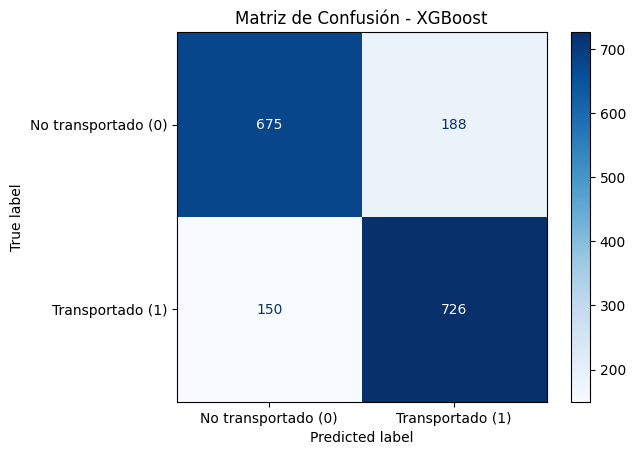

In [ ]:
evaluar_spaceship_model(y_test, y_pred_best_xgb, "XGBoost")

**Interpretación:**
El modelo XGBoost con los hiperparámetros óptimos encontrados mediante el grid search obtuvo un 80.2% de acccuracy.

Como se observa en la matriz de confusión, ell modelo XGBoost comete 157 errores de tipo 2 (falsos negativos) y 187 errores de tipo 1 (falsos positios), por lo que el modelo se equivoca con mayor frecuencia asumiendo que un pasajero si fue transportado cuando en realidad no lo fue, un tipo de error que en el punto 2 consideramos menos grave.

Esto se refleja en el recall de 82.08%, el modelo deja escapar aproximadamente 18% de los pasajeros que realmente sufrieron el accidente, que equivale a los 157 falsos negativos.

Este error de aproximadamente 18% sigue representando un error muy grave, ya que el sistema asume que estos pasajeros están a salvo y no los reporta como desaparecidos, por lo que no se realiza ningun esfuerzo de búsqueda y rescate para 157 personas.

Por otro lado la presición de 79.36% y la specificity de 78.33% reflejan el otro lado del tradeoff, el modelo marca como transportados a varios pasajeros que en realidad no lo fueron, lo cual implica destinar recursos de búsqueda a personas que no necesitan rescate, lo cual sería un costo operativo muy grande, pero sin concecuencias fatales como lo es en el caso anterior.

El modelo finalmente logra cometer más errores de los que el negocio puede permitirse que del que buscac minimizar, pero se busca mejorar estas métricas para minimizar el número de gente desaparecida que clasificamos correctamente.


## 4. Comparativa de modelos

- Genera una tabla resumen con las métricas de todos los modelos entrenados, incluyendo el baseline.
- Elige el mejor modelo y justifica tu elección con evidencia de la tabla. La justificación no puede ser solo tiene el accuracy más alto, argumenta con todas las métricas.
- Genera una visualización comparativa.

In [ ]:
from sklearn.dummy import DummyClassifier

def calcular_metricas(y_test, y_pred, modelo_nombre):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Modelo": modelo_nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Specificity": tn / (tn + fp),
        "FN": fn,
        "FP": fp
    }

# Baseline: predice siempre la clase mayoritaria (Transported = 1),
# el minimo desempeño que cualquier modelo entrenado debe superar.
baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

resultados = [
    calcular_metricas(y_test, y_pred_baseline, "Baseline (clase mayoritaria)"),
    calcular_metricas(y_test, y_pred_best_rf, "Random Forest"),
    calcular_metricas(y_test, y_pred_best_xgb, "XGBoost"),
]

tabla_comparativa = pd.DataFrame(resultados).set_index("Modelo").round(4)
tabla_comparativa


,Accuracy,Precision,Recall,F1-score,Specificity,FN,FP
Modelo,,,,,,,
Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.6700,0.0000,0,863
Random Forest,0.8062,0.8101,0.8037,0.8069,0.8088,172,165
XGBoost,0.8056,0.7943,0.8288,0.8112,0.7822,150,188


**Justificación del modelo elegido**

| Modelo | Accuracy | Precision | Recall | F1-score | Specificity | FN | FP |
|---|---|---|---|---|---|---|---|
| Baseline (clase mayoritaria) | 0.5037 | 0.5037 | 1.0000 | 0.6700 | 0.0000 | 0 | 863 |
| Random Forest | 0.8062 | 0.8101 | 0.8037 | 0.8069 | 0.8088 | 172 | 165 |
| XGBoost | 0.8022 | 0.7936 | 0.8208 | 0.8070 | 0.7833 | 157 | 187 |

Ambos modelos superan ampliamente al baseline: el baseline solo alcanza un recall de 1.0 y un accuracy de 50.37% porque predice siempre "Transportado", lo cual es matemáticamente trivial e inútil en la práctica (specificity de 0%, ningún pasajero no transportado es identificado correctamente). Ese es el piso que cualquier modelo entrenado debe superar en todas las métricas simultáneamente, no solo en accuracy.

**El modelo elegido es XGBoost**, y no es simplemente por tener el accuracy más alto (de hecho no lo tiene: 80.22% vs 80.62% de Random Forest). La elección se basa en el criterio de decisión definido en la sección 2, donde establecimos que el **recall es la métrica principal** porque el costo de negocio de un falso negativo (dejar a un pasajero transportado sin reportar como desaparecido) es mucho mayor que el de un falso positivo (destinar recursos de búsqueda a alguien que no lo necesitaba):

- **Recall:** XGBoost obtiene 82.08% frente a 80.37% de Random Forest. En términos absolutos, XGBoost comete 157 falsos negativos contra 172 de Random Forest, es decir, identifica correctamente a 15 personas más que sí fueron transportadas y que Random Forest dejaría sin buscar. Dado que este es el error que el negocio busca minimizar por encima de todo, esta diferencia es la evidencia más relevante para la decisión.
- **F1-score:** Prácticamente empatado (80.70% XGBoost vs 80.69% Random Forest). Esto confirma que la ganancia en recall de XGBoost no es trivial ni proviene de sacrificar precision de forma desproporcionada; el balance global entre precision y recall se mantiene equivalente entre ambos modelos.
- **Accuracy:** La diferencia es mínima (80.22% vs 80.62%, 0.4 puntos porcentuales) y no es una diferencia relevante para diferenciar modelos, dado que las clases están balanceadas y ambos modelos rinden de forma muy similar en esta métrica general.
- **Precision y Specificity:** Random Forest es superior en ambas (81.01% vs 79.36% en precision, 80.88% vs 78.33% en specificity), lo que significa que comete menos falsos positivos (165 vs 187). Sin embargo, según el análisis de negocio de la sección 2, el falso positivo es el error menos costoso (recursos de búsqueda desperdiciados, sin consecuencias humanas irreversibles), por lo que esta ventaja de Random Forest pesa menos en la decisión final.

En resumen, XGBoost sacrifica una pequeña cantidad de precision/specificity (más falsos positivos, el error "barato") a cambio de una mejora real en recall (menos falsos negativos, el error "caro"), sin perder terreno en F1 ni en accuracy. Por eso es el modelo elegido para continuar con el componente individual de exploración de hiperparámetros.


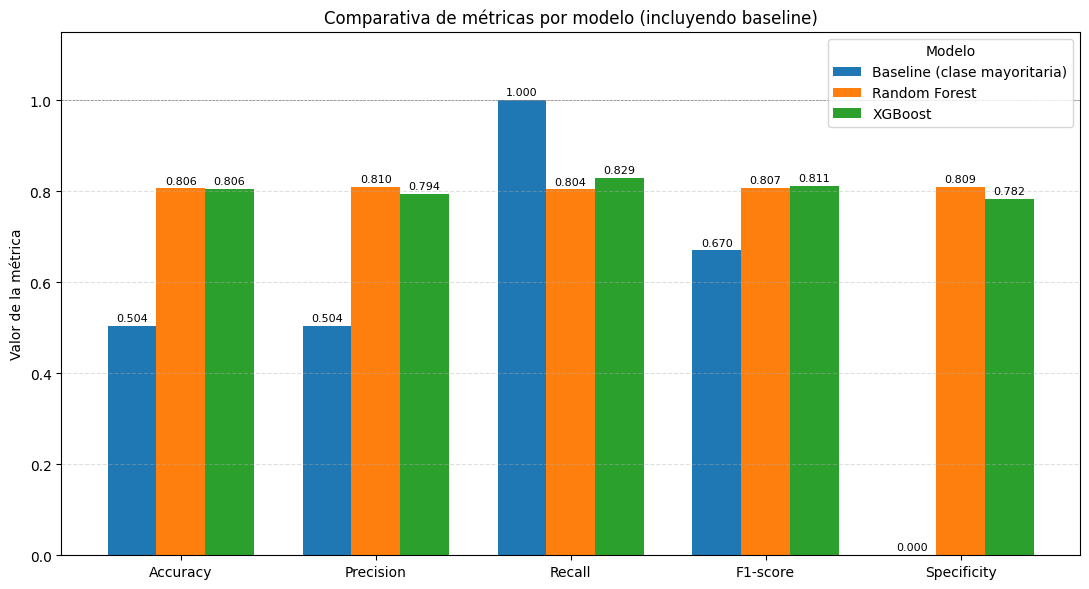

In [ ]:
# Visualización comparativa de métricas por modelo
import numpy as np
metricas_plot = ["Accuracy", "Precision", "Recall", "F1-score", "Specificity"]
modelos_plot = tabla_comparativa.index.tolist()

x = np.arange(len(metricas_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

for i, modelo in enumerate(modelos_plot):
    valores = tabla_comparativa.loc[modelo, metricas_plot].values
    barras = ax.bar(x + (i - 1) * width, valores, width, label=modelo)
    ax.bar_label(barras, fmt="%.3f", padding=2, fontsize=8)

ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparativa de métricas por modelo (incluyendo baseline)")
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot)
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color="gray", linewidth=0.5, linestyle="--")
ax.legend(title="Modelo")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


## 5. Componente individual: Exploración de hiperparámetros

Esta sección debe tener una subsección por cada integrante del equipo, identificada con su nombre completo. Cada integrante trabajará de forma independiente sobre el mejor modelo elegido en el paso 4:

- Elige un hiperparámetro del modelo, justifica por qué lo cambiaste y qué esperabas que pasara.
- Reentrena el modelo con ese cambio.
- Reporta las métricas antes y después del cambio.
- Interpreta el resultado: ¿mejoró?, ¿empeoró?, ¿por qué crees que pasó eso?
- Cada integrante debe cambiar un hiperparámetro distinto. No se acepta que dos integrantes modifiquen el mismo parámetro.

### Sofia Valeria Ramirez Moreno (n_estimators)

**Hiperparámetro elegido: `n_estimators`**

Trabajo sobre el modelo ganador del paso 4, **XGBoost**, con el resto de sus hiperparámetros óptimos fijos (`learning_rate=0.1`, `max_depth=3`, `min_child_weight=1`, `subsample=0.8`), tal como los encontró el Grid Search.

Elegí `n_estimators` (número de árboles secuenciales) porque el Grid Search lo dejó en el valor más bajo del espacio de búsqueda (100, frente a las opciones 300 y 500), y quería comprobar si esa elección realmente era la óptima o si el buscador se había quedado "corto".

**Hipótesis:** esperaba que al aumentar `n_estimators` de 100 a 500 el modelo mejorara, sobre todo el *recall* (la métrica prioritaria definida en el paso 2), ya que en un ensamble más grande el modelo tiene más oportunidades de corregir errores de las rondas anteriores. Como riesgo, también consideré que un número demasiado alto de árboles, con el `learning_rate` fijo en 0.1, podría empezar a sobreajustar el set de entrenamiento.

In [ ]:
from xgboost import XGBClassifier

# Hiperparámetros óptimos encontrados por el Grid Search (paso 3) para el modelo ganador (XGBoost),
# manteniendo todo fijo excepto n_estimators
base_params_xgb = {
    'learning_rate': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,
    'subsample': 0.8,
    'random_state': 42,
    'eval_metric': 'logloss'
}

# --- ANTES: n_estimators = 100 (valor óptimo hallado por el Grid Search) ---
n_estimators_antes = 100
modelo_antes = XGBClassifier(n_estimators=n_estimators_antes, **base_params_xgb)
modelo_antes.fit(X_train, y_train)
y_pred_antes = modelo_antes.predict(X_test)
metricas_antes = calcular_metricas(y_test, y_pred_antes, f"XGBoost (n_estimators={n_estimators_antes})")

# --- DESPUÉS: aumentamos considerablemente el número de árboles secuenciales ---
n_estimators_despues = 500
modelo_despues = XGBClassifier(n_estimators=n_estimators_despues, **base_params_xgb)
modelo_despues.fit(X_train, y_train)
y_pred_despues = modelo_despues.predict(X_test)
metricas_despues = calcular_metricas(y_test, y_pred_despues, f"XGBoost (n_estimators={n_estimators_despues})")

# Tabla comparativa antes / después
tabla_n_estimators = pd.DataFrame([metricas_antes, metricas_despues]).set_index("Modelo").round(4)
tabla_n_estimators

,Accuracy,Precision,Recall,F1-score,Specificity,FN,FP
Modelo,,,,,,,
XGBoost (n_estimators=100),0.8056,0.7943,0.8288,0.8112,0.7822,150,188
XGBoost (n_estimators=500),0.8079,0.8025,0.8208,0.8115,0.7949,157,177


### Santiago Serrano Montalvo (max_depth)

{'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}
--- Evaluación de: XGBoost max_depth ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.8288

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.8112

Métricas de Referencia / Contexto:
 * Accuracy:    0.8056
 * Precision:   0.7943
 * Specificity: 0.7822

Generando Matriz de Confusión...


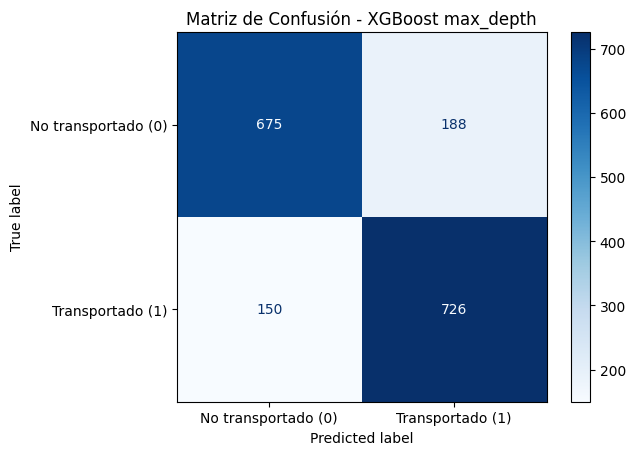

           Recall (CV)
max_depth             
2             0.822673
3             0.833812
4             0.816388
5             0.806968
7             0.792115
9             0.784406
12            0.777263


,Accuracy,Precision,Recall,F1-score,Specificity,FN,FP
Modelo,,,,,,,
"XGBoost (max_depth=3, antes)",0.805635,0.794311,0.828767,0.811173,0.782155,150,188
"XGBoost (max_depth=9, después)",0.820587,0.827146,0.813927,0.820483,0.827346,163,149


In [ ]:
param_grid_depth = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'min_child_weight': [1],
    'subsample': [0.8],
    'max_depth': [2, 3, 4, 5, 7, 9, 12]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
grid_depth = GridSearchCV(xgb_base, param_grid_depth, scoring='recall', cv=5)
grid_depth.fit(X_train, y_train)

print(grid_depth.best_params_)

y_pred_depth = grid_depth.best_estimator_.predict(X_test)

evaluar_spaceship_model(y_test, y_pred_depth, "XGBoost max_depth")

resultados_depth = pd.DataFrame({
    "max_depth": grid_depth.cv_results_["param_max_depth"].data,
    "Recall (CV)": grid_depth.cv_results_["mean_test_score"]
}).set_index("max_depth")

modelo_depth_alto = XGBClassifier(
    n_estimators=100, max_depth=9, learning_rate=0.1,
    min_child_weight=1, subsample=0.8,
    random_state=42, eval_metric='logloss'
)
modelo_depth_alto.fit(X_train, y_train)
y_pred_depth_alto = modelo_depth_alto.predict(X_test)

comparativa_depth = pd.DataFrame([
    calcular_metricas(y_test, y_pred_depth, "XGBoost (max_depth=3, antes)"),
    calcular_metricas(y_test, y_pred_depth_alto, "XGBoost (max_depth=9, después)")
]).set_index("Modelo")

print(resultados_depth)
comparativa_depth

**Hiperparámetro elegido: `max_depth`**

Se evaluó `max_depth` en XGBoost porque controla la profundidad de los árboles.
El paso 4 solo probó 3, 5 y 7, así que se aumento el barrido a 2, 3, 4, 5, 7, 9, 12 para verificar si 3 era realmente el óptimo.

**Hipótesis:** aumentar la profundidad podría ayudar a encontrar patrones más
complejos, pero con riesgo de sobreajuste.

**Interpretación**

El recall en validación cruzada fue mayor en `max_depth=3` y bajó al alejarse
del valor tanto hacia arriba como hacia abajo, confirmando que sí es un óptimo.

En test, `max_depth=9` supera al modelo en accuracy, precision, specificity y F1,
pero pierde recall (81.39% vs 82.88%): quita 39 FP pero con 13
FN más. Por lo que bajo
el criterio del paso 2 se conserva `max_depth=3`.

### Roberd Meza Sainz (Learning_rate)

In [ ]:
# Modelo original
xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    min_child_weight=1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)


# Modelo actualizado
xgb_base_2 = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.065,
    min_child_weight=1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_base_2.fit(X_train, y_train)
y_pred_xgb_2 = xgb_base_2.predict(X_test)



--- Evaluación de: XGBoost con learning rate actualizado ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.8368

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.8131

Métricas de Referencia / Contexto:
 * Accuracy:    0.8062
 * Precision:   0.7907
 * Specificity: 0.7752

Generando Matriz de Confusión...


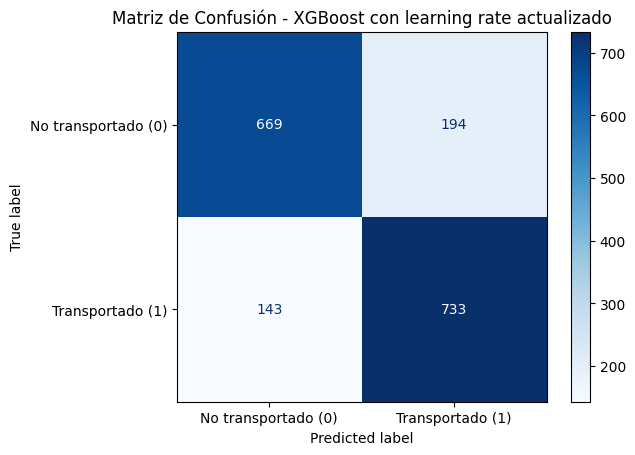

,Accuracy,Recall,F1-Score,Precision
Modelo,,,,
XGBoost original,0.8056,0.8288,0.8112,0.7943
XGBoost learning rate actualizado,0.8062,0.8368,0.8131,0.7907


In [ ]:
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score


evaluar_spaceship_model(
    y_test,
    y_pred_xgb_2,
    "XGBoost con learning rate actualizado"
)

# Modelo original
metricas_antes = {
    "Modelo": "XGBoost original",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1-Score": f1_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb)
}

# Modelo actualizado
metricas_despues = {
    "Modelo": "XGBoost learning rate actualizado",
    "Accuracy": accuracy_score(y_test, y_pred_xgb_2),
    "Recall": recall_score(y_test, y_pred_xgb_2),
    "F1-Score": f1_score(y_test, y_pred_xgb_2),
    "Precision": precision_score(y_test, y_pred_xgb_2)
}

tabla_n_estimators = pd.DataFrame([metricas_antes, metricas_despues]).set_index("Modelo").round(4)

tabla_n_estimators

**Interpretación**

Tras cambiar progresivamente la métrica de `learning_rate` realizé pruebas progresivas comenzando por el valor original de .1, y cambiandolo gradualmente, primero intenté aumentarlo pero los cambios eran desfavorables por lo que mi siguiente estrategia fué reducirlo gradualmente. Durante las pruebas se observó que el desempeño de las métricas mejoraba conforme se disminuía el valor, hasta alcanzar `learning_rate = 0.065`. Al continuar reduciéndolo por debajo de .065, las métricas comenzaron nuevamente a disminuir. De igual manera al usar valores mayores a .065 resultaba en un menor desempeño, por lo que se seleccionó finalmente a **0.065** como el valor que presentó el mejor desempeño general en términos de recall.

### Andrés Méndez Cortez (min_child_weight)

In [ ]:
# Definir los valores de min_child_weight a evaluar
param_grid = {
    'min_child_weight': [ 3,7,10,15]
}

# Configurar el modelo base
xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Configurar GridSearchCV
# return_train_score=True para extraer los datos de entrenamiento para la gráfica
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',
    n_jobs=-1,
    return_train_score=True
)

# Ajustar el modelo usando los datos de entrenamiento
print("Evaluando valores de min_child_weight...")
grid_search.fit(X_train, y_train)

# Extraer y mostrar el mejor resultado
best_min_child = grid_search.best_params_['min_child_weight']
print(f"\n¡El mejor valor para min_child_weight es: {best_min_child}!")
print(f"Mejor score de validación (Recall)): {grid_search.best_score_:.4f}")

Evaluando valores de min_child_weight...

¡El mejor valor para min_child_weight es: 3!
Mejor score de validación (Recall)): 0.8312


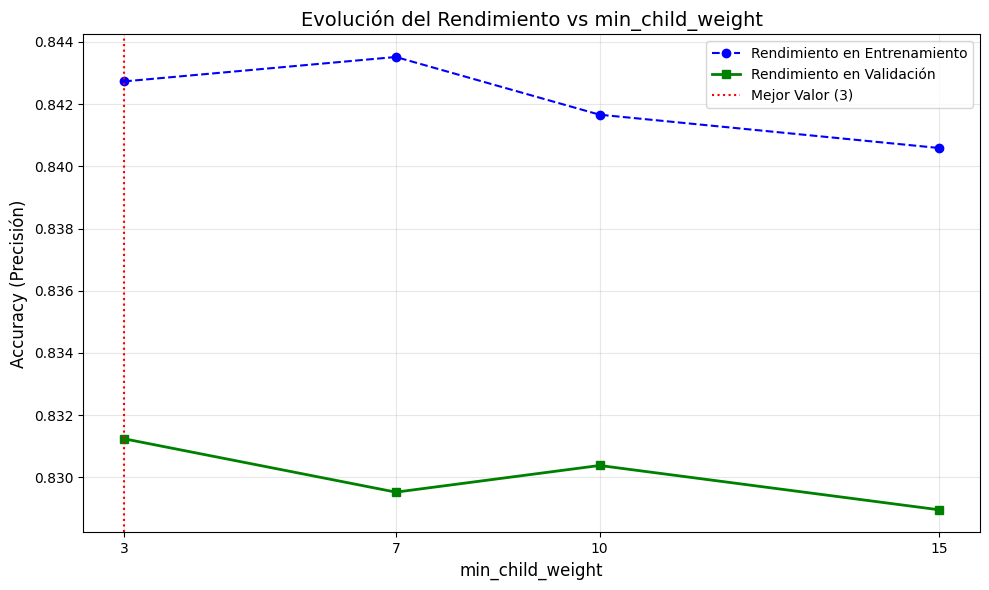

In [ ]:
# Extraer los resultados del grid search
results = grid_search.cv_results_
valores_min_child = results['param_min_child_weight'].data
scores_train = results['mean_train_score']
scores_test = results['mean_test_score']

# Crear la gráfica
plt.figure(figsize=(10, 6))

# Trazar el rendimiento de entrenamiento y validación (test)
plt.plot(valores_min_child, scores_train, label='Rendimiento en Entrenamiento', marker='o', linestyle='--', color='blue')
plt.plot(valores_min_child, scores_test, label='Rendimiento en Validación', marker='s', linewidth=2, color='green')

# Resaltar el mejor valor en la gráfica
plt.axvline(x=best_min_child, color='red', linestyle=':', label=f'Mejor Valor ({best_min_child})')

# Configurar detalles del gráfico
plt.title('Evolución del Rendimiento vs min_child_weight', fontsize=14)
plt.xlabel('min_child_weight', fontsize=12)
plt.ylabel('Accuracy (Precisión)', fontsize=12)
plt.xticks(param_grid['min_child_weight'])
plt.legend()
plt.grid(True, alpha=0.3)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

# Opcional: Si quieres usar directamente el modelo ya optimizado para predecir
# grid_search.best_estimator_ contiene el modelo con el mejor parámetro ya ajustado
y_pred_optimizado = grid_search.predict(X_test)

--- Evaluación de: XGBoost (min_child_weight=3) ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.8333

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.8138

Métricas de Referencia / Contexto:
 * Accuracy:    0.8079
 * Precision:   0.7952
 * Specificity: 0.7822

Generando Matriz de Confusión...


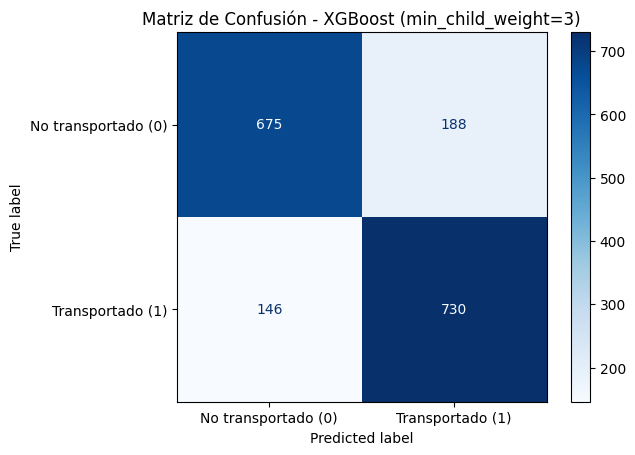

In [ ]:
evaluar_spaceship_model(
    y_test=y_test,
    y_pred=y_pred_optimizado,
    modelo_nombre=f"XGBoost (min_child_weight={best_min_child})"
)

**Interpretación**

El análisis de la evolución de las métricas demuestra que, a medida que se incrementa el valor de min_child_weight, el desempeño general del modelo se degrada. Esto ocurre porque valores más altos vuelven al algoritmo demasiado conservador, exigiéndole una mayor cantidad de muestras para justificar nuevas divisiones en los árboles. Como resultado, el modelo sufre de subajuste y pierde flexibilidad, volviéndose incapaz de capturar los patrones más sutiles en los datos que son necesarios para clasificar correctamente. Por lo tanto, para este problema en particular, es indispensable mantener un valor bajo que permita un aprendizaje más detallado, en este caso, excluyendo el valor original de 1, el siguiente mejor es el de 3 que mejora en un 1% el desempeño en el recall.

### Saúl Caballero Castor (subsample)

`subsample` se encarga de controlar el porcentaje de datos de entrenamiento que usa cada árbol. El objetivo de esta exploración es ver si algun valor podría mejorar el valor de 0.8 encontrado en el paso 4, esto con la meta de mejorar el recall.

**Hipótesis**: Se espera que un subsample distinto a 0.8 (tanto mayor como menor) pueda mejorar el recall sin afectar mucho las otras métricas

In [ ]:
param_grid_xgb = {
    'n_estimators': [100],
    'max_depth': [3],
    'learning_rate': [0.1],
    'min_child_weight': [1],
    'subsample': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

grid_xgb = GridSearchCV(xgb_base, param_grid_xgb, scoring='recall', cv=5)
grid_xgb.fit(X_train, y_train)

y_pred_best_xgb = grid_xgb.best_estimator_.predict(X_test)
print(grid_xgb.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}


--- Evaluación de: XGBoost subsample ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.8288

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.8112

Métricas de Referencia / Contexto:
 * Accuracy:    0.8056
 * Precision:   0.7943
 * Specificity: 0.7822

Generando Matriz de Confusión...


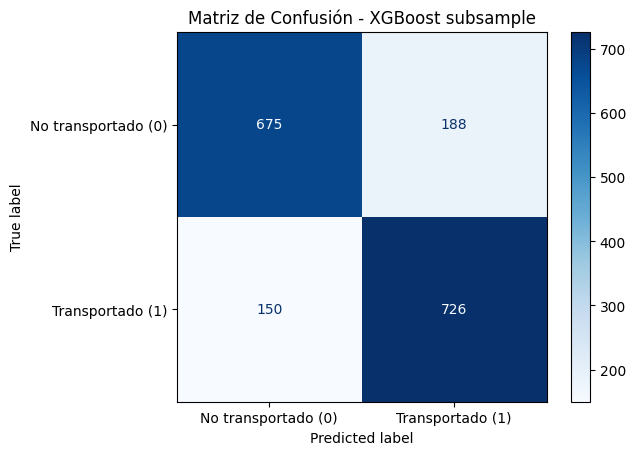

In [ ]:
evaluar_spaceship_model(y_test, y_pred_best_xgb, "XGBoost subsample")

El grid search se encargó de evaluar todos los valores posibles de subsample y confirmó que 0.8 es el mejor valor posible para esta combinación de hiperparámetros, por lo que las métricas no cambian con respecto al modelo del paso 4. Esto sugiere que que el punto de balance entre sesgo y varianza para este dataset ya se encontraba en 0.8 naturalmente, y que el margen de mejora del modelo probablemente se encuentre en la exploración de otro hiperparámetro.

## 6. Verificación y cierre

- Tabla resumen final: Modelo, hiperparámetros usados, métricas principales, decisión (elegido / descartado).
- Conclusión del equipo: ¿qué aprendieron del comportamiento de los modelos sobre este dataset?, ¿qué harían diferente en la siguiente iteración?

In [ ]:
import pandas as pd
resumen_final = pd.DataFrame([
    {
        "Modelo": "Baseline (clase mayoritaria)",
        "Hiperparámetros": "strategy='most_frequent'",
        "Accuracy": 0.5037, "Precision": 0.5037, "Recall": 1.0000,
        "F1-score": 0.6700, "Specificity": 0.0000,
        "FN": 0, "FP": 863,
        "Decisión": "Descartado (referencia)"
    },
    {
        "Modelo": "Random Forest",
        "Hiperparámetros": "max_depth=12, min_samples_split=20, n_estimators=500",
        "Accuracy": 0.8062, "Precision": 0.8101, "Recall": 0.8037,
        "F1-score": 0.8069, "Specificity": 0.8088,
        "FN": 172, "FP": 165,
        "Decisión": "Descartado"
    },
    {
        "Modelo": "XGBoost (paso 4)",
        "Hiperparámetros": "n_estimators=100, max_depth=3, learning_rate=0.1, min_child_weight=1, subsample=0.8",
        "Accuracy": 0.8056, "Precision": 0.7943, "Recall": 0.8288,
        "F1-score": 0.8112, "Specificity": 0.7822,
        "FN": 150, "FP": 188,
        "Decisión": "Elegido como base"
    },
    {
        "Modelo": "XGBoost + n_estimators=500",
        "Hiperparámetros": "n_estimators=500, resto igual al base",
        "Accuracy": 0.8079, "Precision": 0.8025, "Recall": 0.8208,
        "F1-score": 0.8115, "Specificity": 0.7949,
        "FN": 157, "FP": 177,
        "Decisión": "Descartado"
    },
    {
        "Modelo": "XGBoost + max_depth",
        "Hiperparámetros": "max_depth=3 (confirmado por barrido), resto igual al base",
        "Accuracy": 0.8056, "Precision": 0.7943, "Recall": 0.8288,
        "F1-score": 0.8112, "Specificity": 0.7822,
        "FN": 150, "FP": 188,
        "Decisión": "Sin cambio respecto al base"
    },
    {
        "Modelo": "XGBoost + learning_rate=0.065",
        "Hiperparámetros": "learning_rate=0.065, resto igual al base",
        "Accuracy": 0.8062, "Precision": 0.7907, "Recall": 0.8368,
        "F1-score": 0.8131, "Specificity": 0.7752,
        "FN": 143, "FP": 194,
        "Decisión": "Elegido (modelo final)"
    },
    {
        "Modelo": "XGBoost + min_child_weight=3",
        "Hiperparámetros": "min_child_weight=3, resto igual al base",
        "Accuracy": 0.8079, "Precision": 0.7952, "Recall": 0.8333,
        "F1-score": 0.8138, "Specificity": 0.7822,
        "FN": 146, "FP": 188,
        "Decisión": "Descartado (segunda mejor opción)"
    },
    {
        "Modelo": "XGBoost + subsample",
        "Hiperparámetros": "subsample=0.8 (confirmado por barrido), resto igual al base",
        "Accuracy": 0.8056, "Precision": 0.7943, "Recall": 0.8288,
        "F1-score": 0.8112, "Specificity": 0.7822,
        "FN": 150, "FP": 188,
        "Decisión": "Sin cambio respecto al base"
    },
]).set_index("Modelo")

resumen_final

,Hiperparámetros,Accuracy,Precision,Recall,F1-score,Specificity,FN,FP,Decisión
Modelo,,,,,,,,,
Baseline (clase mayoritaria),strategy='most_frequent',0.5037,0.5037,1.0000,0.6700,0.0000,0,863,Descartado (referencia)
Random Forest,"max_depth=12, min_samples_split=20, n_estimato...",0.8062,0.8101,0.8037,0.8069,0.8088,172,165,Descartado
XGBoost (paso 4),"n_estimators=100, max_depth=3, learning_rate=0...",0.8056,0.7943,0.8288,0.8112,0.7822,150,188,Elegido como base
XGBoost + n_estimators=500,"n_estimators=500, resto igual al base",0.8079,0.8025,0.8208,0.8115,0.7949,157,177,Descartado
XGBoost + max_depth,"max_depth=3 (confirmado por barrido), resto ig...",0.8056,0.7943,0.8288,0.8112,0.7822,150,188,Sin cambio respecto al base
XGBoost + learning_rate=0.065,"learning_rate=0.065, resto igual al base",0.8062,0.7907,0.8368,0.8131,0.7752,143,194,Elegido (modelo final)
XGBoost + min_child_weight=3,"min_child_weight=3, resto igual al base",0.8079,0.7952,0.8333,0.8138,0.7822,146,188,Descartado (segunda mejor opción)
XGBoost + subsample,"subsample=0.8 (confirmado por barrido), resto ...",0.8056,0.7943,0.8288,0.8112,0.7822,150,188,Sin cambio respecto al base


**Conclusión del equipo**

Durante esta iteración observamos que XGBoost y Random Forest obtuvieron resultados
muy similares, con un accuracy cercano al 80%. Esto indica que la principal
limitación del modelo probablemente está en la información disponible en las
variables y no en el algoritmo utilizado.

También confirmamos que el accuracy no era suficiente para elegir el mejor
modelo. Debido al objetivo del problema, el recall fue la métrica principal,
ya que buscamos reducir la cantidad de pasajeros que el modelo no detecta. Por
esta razón se seleccionó XGBoost con `learning_rate=0.065`, ya que redujo los
falsos negativos de 150 a 143.

Las pruebas de hiperparámetros mostraron que el modelo ya estaba cerca de su
mejor configuración. `max_depth` y `subsample` no generaron mejoras, mientras
que `learning_rate` y `min_child_weight` tuvieron cambios pequeños en el recall.
Además, como las comparaciones se realizaron sobre el mismo conjunto de prueba
usado para elegir el modelo, el resultado final puede estar ligeramente
sobreestimado.

Para una siguiente iteración sería más útil ajustar el umbral de clasificación
usando las probabilidades del modelo, ya que permitiría controlar mejor el
balance entre falsos positivos y falsos negativos. También sería recomendable
usar validación cruzada y mejorar la ingeniería de variables para obtener más
información del dataset.

---
# Tercer Avance
---

## 1. Diagnóstico del modelo base

- Genera la curva de aprendizaje del mejor modelo de tu entrega anterior.
- Genera la curva de validación para al menos dos hiperparámetros relevantes de dicho modelo.
- Interpreta ambas curvas: ¿hay overfitting?, ¿underfitting?, ¿necesitas más datos?, ¿qué rango de hiperparámetros tiene sentido explorar?

In [ ]:
#librerias
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve

In [ ]:
#modelo
xgb_lc = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.065,
    min_child_weight=1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

### Curvas de aprendizaje

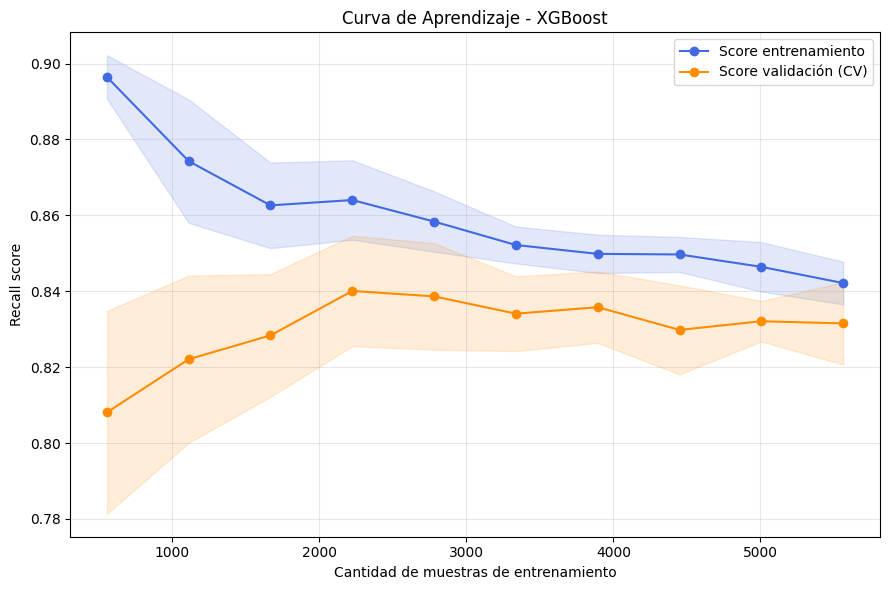

In [ ]:
#Curva de aprendizaje del recall (metrica principal)
# Tamaños de entrenamiento a evaluar (10%, 20%, ..., 100% de los datos)
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=xgb_lc,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=5,                      # validación cruzada de 5 folds
    scoring='recall',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Promedios y desviaciones estándar
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Gráfico
plt.figure(figsize=(9, 6))
plt.plot(train_sizes_abs, train_mean, 'o-', color='royalblue', label='Score entrenamiento')
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                  alpha=0.15, color='royalblue')

plt.plot(train_sizes_abs, val_mean, 'o-', color='darkorange', label='Score validación (CV)')
plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                  alpha=0.15, color='darkorange')

plt.title('Curva de Aprendizaje - XGBoost')
plt.xlabel('Cantidad de muestras de entrenamiento')
plt.ylabel('Recall score')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

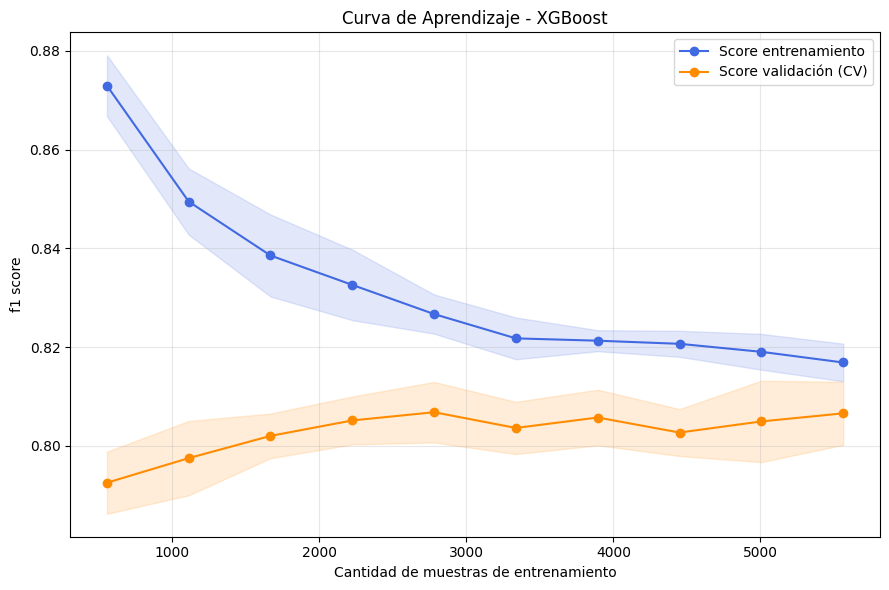

In [ ]:
#Curva de aprendizaje del f1 score (metrica secundaria)
#Tamaños de entrenamiento a evaluar (10%, 20%, ..., 100% de los datos)
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=xgb_lc,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=5,                      # validación cruzada de 5 folds
    scoring='f1',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Promedios y desviaciones estándar
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Gráfico
plt.figure(figsize=(9, 6))
plt.plot(train_sizes_abs, train_mean, 'o-', color='royalblue', label='Score entrenamiento')
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                  alpha=0.15, color='royalblue')

plt.plot(train_sizes_abs, val_mean, 'o-', color='darkorange', label='Score validación (CV)')
plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                  alpha=0.15, color='darkorange')

plt.title('Curva de Aprendizaje - XGBoost')
plt.xlabel('Cantidad de muestras de entrenamiento')
plt.ylabel('f1 score')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Curvas de validación
Aunque las instrucciones indican que se realicen las curvas de los dos parámetros más importantes, se creyó pertinente analizar los primeros tres, los cuales son *('n_estimators')* *('max_depth')* *('learning_rate')* esto debido a que aunque los primeros dos parametros son indiscutiblemente los más decisivos en el modelo, en el ejercicio anterior encontramos nuestro una mejora al modelo base modificando el *learning rate*.



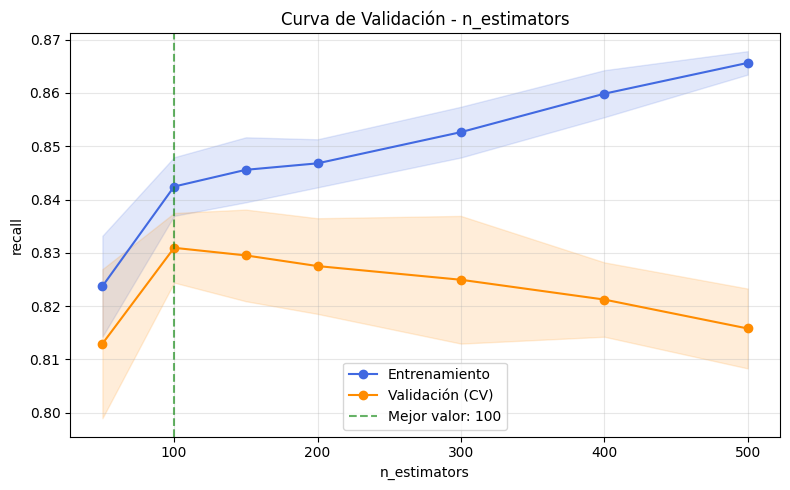

n_estimators: mejor valor = 100 (score=0.8310)


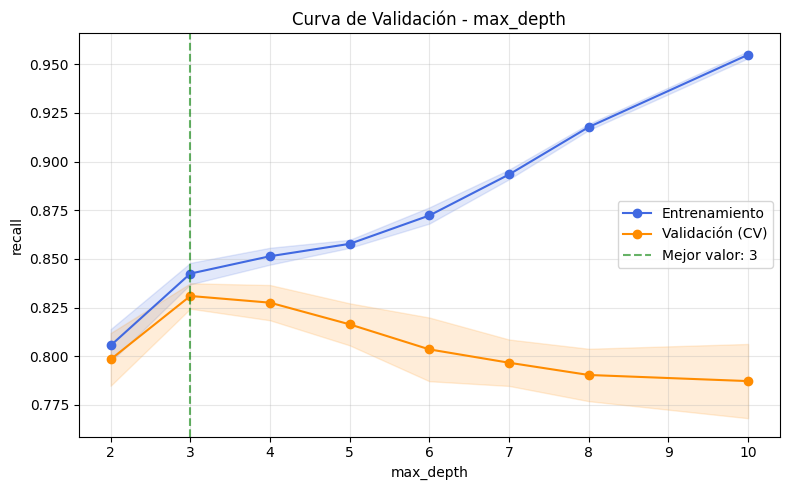

max_depth: mejor valor = 3 (score=0.8310)


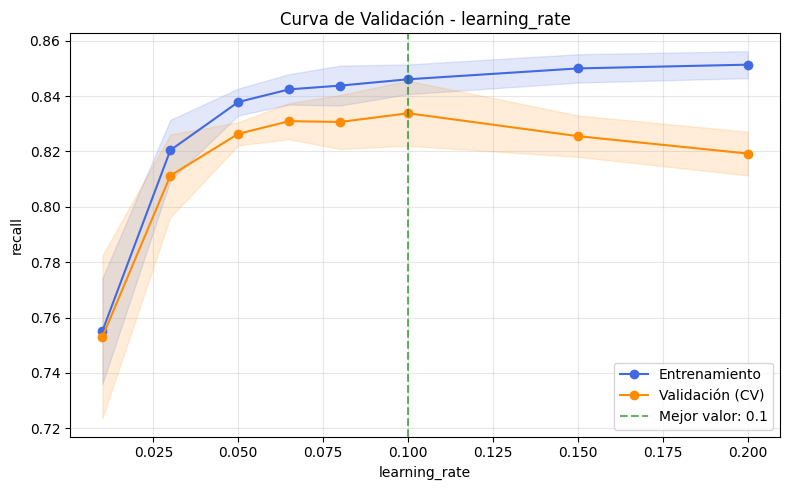

learning_rate: mejor valor = 0.1 (score=0.8338)

Resumen de mejores valores individuales:
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.1


In [ ]:
#curvas de validación

# Parámetros base (fijos) — se usan como referencia para todos los gráficos
base_params = dict(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.065,
    min_child_weight=1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Diccionario: parámetro -> rango de valores a probar
param_grid = {
    'n_estimators':     [50, 100, 150, 200, 300, 400, 500],
    'max_depth':        [2, 3, 4, 5, 6, 7, 8, 10],
    'learning_rate':    [0.01, 0.03, 0.05, 0.065, 0.08, 0.1, 0.15, 0.2],
}

def plot_validation_curve(param_name, param_range, cv=5, scoring='recall'):
    # Modelo base sin el parámetro que vamos a variar
    params = {k: v for k, v in base_params.items() if k != param_name}

    train_scores, val_scores = validation_curve(
        estimator=XGBClassifier(**params),
        X=X_train,
        y=y_train,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(param_range, train_mean, 'o-', color='royalblue', label='Entrenamiento')
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std,
                      alpha=0.15, color='royalblue')

    plt.plot(param_range, val_mean, 'o-', color='darkorange', label='Validación (CV)')
    plt.fill_between(param_range, val_mean - val_std, val_mean + val_std,
                      alpha=0.15, color='darkorange')

    # Marca el mejor valor según validación
    best_idx = np.argmax(val_mean)
    plt.axvline(param_range[best_idx], color='green', linestyle='--', alpha=0.6,
                label=f'Mejor valor: {param_range[best_idx]}')

    plt.title(f'Curva de Validación - {param_name}')
    plt.xlabel(param_name)
    plt.ylabel(scoring)
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return param_range[best_idx], val_mean[best_idx]

# Generar la curva para cada parámetro
best_values = {}
for param_name, param_range in param_grid.items():
    best_val, best_score = plot_validation_curve(param_name, param_range)
    best_values[param_name] = best_val
    print(f"{param_name}: mejor valor = {best_val} (score={best_score:.4f})")

print("\nResumen de mejores valores individuales:")
for k, v in best_values.items():
    print(f"  {k}: {v}")

### Interpretación de las curvas
####Curvas de aprendizaje
El modelo presenta un fit prácticamente adecuado, con muy leve tendencia a underfitting: las curvas de aprendizaje muestran que tanto el score de entrenamiento como el de validación convergen hacia una brecha pequeña (0.01-0.02), descartando overfitting severo, pero la curva de validación se aplana a partir de las 2000-2500 muestras oscilando sin tendencia clara de seguir subiendo pese a duplicarse el tamaño del set de entrenamiento, e incluso el score de entrenamiento también desciende y se estabiliza en un nivel relativamente bajo (0.82-0.84) en vez de mantenerse alto; esto sugiere que el modelo no está sufriendo de alta varianza y no está limitado por falta de datos, sino que alcanzó un techo de desempeño consistente con un problema de sesgo o de información disponible en las features, por lo que agregar más muestras del mismo tipo de datos tendría rendimientos marginales decrecientes y no rompería ese techo. La vía de mejora está en la calidad y capacidad representativa de los datos/modelo, no en su cantidad.


####Curvas de validación
De acuerdo a las curvas de validación se puede nver los siguientes rangos recomendados:

n_estimators: El score de validación alcanza su pico en 100 y decae de forma sostenida a partir de ahí (100→500), mientras el train sigue subiendo — señal clara de overfitting creciente con más árboles. Rango sensato: 75–150 (evitar irse mucho más allá de 100-150).

max_depth: El patrón es el más claro de overfitting: validación pico en 3, y cae de forma consistente y pronunciada de 3 a 10, mientras train se dispara hasta 0.95. Rango sensato: 2–4 (no tiene sentido explorar más allá de 5, el daño ya es evidente).

learning_rate: Validación sube fuerte de 0.01 a 0.05-0.10 (train y val convergen bien ahí), luego empieza a decaer levemente después de 0.10. Rango sensato: 0.03–0.10.

Dado que las curvas de validación ya delimitaron rangos estrechos y bien definidos para cada hiperparámetro clave, la decisión final es usar Grid Search (con cv=5) sobre el siguiente espacio de búsqueda: max_depth en [2, 3, 4], learning_rate en [0.03, 0.05, 0.065, 0.08, 0.10], y n_estimators en [75, 100, 125, 150], dado que un grid exhaustivo es computacionalmente viable en este rango acotado (60 combinaciones) y permite capturar por completo la interacción conocida entre learning_rate y n_estimators, algo que un muestreo aleatorio podría no cubrir de forma completa.

## 2. Tuning de hiperparámetros

- Elige entre GridSearchCV o RandomizedSearchCV y justifica tu elección en función del espacio de búsqueda.
- Define la grilla o distribución de hiperparámetros. Justifica cada rango elegido con base en las curvas de validación del paso anterior.
- No olvides usar K-Fold dentro de la búsqueda de hiperparámetros, elige una K óptima y justifica la elección.
- Reporta los mejores hiperparámetros encontrados y el score en CV.
- Elige mínimo 2 métricas de evaluación justificadas con base en las características del dataset.

In [ ]:
#Balance
conteo = y_train.value_counts()
proporcion = y_train.value_counts(normalize=True)
## 2. Tuning de hiperparámetros

- Elige entre GridSearchCV o RandomizedSearchCV y justifica tu elección en función del espacio de búsqueda.
- Define la grilla o distribución de hiperparámetros. Justifica cada rango elegido con base en las curvas de validación del paso anterior.
- No olvides usar K-Fold dentro de la búsqueda de hiperparámetros, elige una K óptima y justifica la elección.
- Reporta los mejores hiperparámetros encontrados y el score en CV.
- Elige mínimo 2 métricas de evaluación justificadas con base en las características del dataset.
print("Conteo:\n", conteo)
print("\nProporción:\n", proporcion)

SyntaxError: invalid syntax (1687756833.py, line 6)

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, f1_score, classification_report

param_grid = {
    'n_estimators': [75, 100, 125, 150],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.065, 0.08,  0.1],
    'scale_pos_weight': [1, 1.2, 1.5, 2]
}

xgb_base = XGBClassifier(
    min_child_weight=1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor recall promedio en CV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Mejores hiperparámetros encontrados:
{'learning_rate': 0.08, 'max_depth': 2, 'n_estimators': 100, 'scale_pos_weight': 2}

Mejor recall promedio en CV: 0.9038


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score

best_model = grid_search.best_estimator_

f1_scores = cross_val_score(best_model, X_train, y_train, cv=cv_strategy, scoring='f1', n_jobs=-1)
print(f"F1 promedio en CV con el mejor modelo: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
precision_scores = cross_val_score(best_model, X_train, y_train, cv=cv_strategy, scoring='precision', n_jobs=-1)
print(f"Precision promedio en CV: {precision_scores.mean():.4f} (+/- {precision_scores.std():.4f})")

F1 promedio en CV con el mejor modelo: 0.8073 (+/- 0.0085)
Precision promedio en CV: 0.7295 (+/- 0.0094)


**Elección del método de búsqueda**

Se eligió GridSearchCV sobre RandomizedSearchCV porque el espacio de búsqueda ya estaba acotado por las curvas de validación argumentado en el punto anterior. Con 4 valores de n_estimators, 3 de max_depth, 5 de learning_rate y 4 de scale_pos_weight (240 combinaciones) se considera computacionalmente viable.

**Definición y justificación de la grilla**
* `n_estimators: [75, 100, 125, 150]`. La curva de validación del punto 1 mostró el pico de recall en 100, con decaimiento sostenido a partir de ahí conforme el train score seguía subiendo (overfitting creciente). Se buscó con resolución fina alrededor de ese pico.
* `max_depth: [2, 3, 4]`. La curva de validación mostró el patrón de overfitting más marcado de los tres parámetros: pico en 3, caída pronunciada y consistente hacia valores mayores. No tiene sentido explorar más allá de 4.
* `learning_rate: [0.03, 0.05, 0.065, 0.08, 0.1]`. La curva mostró una subida fuerte entre 0.01 y 0.05-0.10, con decaimiento leve después de 0.10. Se cubrió ese rango completo con mayor resolución que en el análisis exploratorio inicial.
* `scale_pos_weight: [1, 1.2, 1.5, 2]`. Este parámetro no proviene del análisis de curvas de validación del punto 1, ya que no fue explorado ahí. Su inclusión responde a un criterio distinto ya que se verificó que las clases están prácticamente balanceadas (50.4% vs 49.6%, ratio negativos/positivos de 0.986), por lo que no existe un problema de desbalance estadístico que corregir. Sin embargo, el costo de los errores no es simétrico para este problema: un falso negativo (no detectar a un pasajero transportado) es el error crítico a minimizar. scale_pos_weight permite introducir concientemente un sesgo hacia el recall en la función de pérdida del modelo, como una decisión de diseño orientada al costo del error, no como una corrección de desbalance de clases.

**Estrategia de validación cruzada**
Se utilizó StratifiedKFold con K=5 con aproximadamente 6954 muestras de entrenamiento, K=5 genera folds de validación de un tamaño suficiente (1390 muestras aprox) para obtener estimaciones estables del recall, sin sacrificar una porción excesiva de datos de entrenamiento en cada partición.

**Mejores hiperparámetros y score en CV**
La búsqueda encontró como óptimo: n_estimators=100, max_depth=2, learning_rate=0.08, scale_pos_weight=2, con un recall promedio en validación cruzada de 0.9038.
Podemos ver que max_depth=2 difiere del pico de 3 encontrado en la curva de validación univariada del punto 1. Esto no necesariamente contradice ese análisis, sino que revela una interacción entre max_depth y scale_pos_weight, la curva de validación del punto 1 se generó con scale_pos_weight=1 fijo, mientras que la búsqueda conjunta permite que ambos parámetros se muevan simultáneamente. Al aumentar el peso de la clase positiva, el punto óptimo de profundidad del árbol se desplaza.

**Métricas de evaluación elegidas y justificación**
Se usaron tres métricas, no solo las dos mínimas requeridas, dado el trade-off que se buscaba explorar deliberadamente:
* **Recall (primaria)**: principal métrica de evaluación del problema, donde un falso negativo (pasajero transportado no detectado) representa el error de mayor costo.
* **Precision (complementaria)**: necesaria para cuantificar el costo de optimizar agresivamente el recall, dado que ambas métricas están en relacionadas directamente.
* **F1-score (de balance)**: permite verificar que la ganancia en recall no se logró a costa de una caída muy grande en la precision.

**Interpretación de los resultados**

| Métrica | Score en CV |
|---|---|
| Recall | 0.9038 |
| Precision | 0.7295 |
| F1-score | 0.8073 |

El tuning con scale_pos_weight logró romper el techo de recall identificado en el diagnóstico del punto 1 (83-85%), llevándolo hasta 90.38%. Este resultado confirma la hipótesis planteada en ese diagnóstico: el modelo base no estaba limitado por una falta de datos ni por una mala calibración de su complejidad (n_estimators, max_depth, learning_rate ya estaban cerca de su óptimo individual), sino por un punto de decisión (el peso implícito 1:1 entre clases en la función de pérdida) que no favorecía la métrica prioritaria del problema.

La mejora tuvo un costo esperado: la precision cayó a 72.95%, reflejando que el modelo ahora clasifica más casos como positivos, incluyendo más falsos positivos, a cambio de capturar más verdaderos positivos. El F1-score de 0.8073 confirma que el balance general se mantiene razonable, sin colapsar, pero el resultado debe leerse explícitamente como una decisión de trade-off alineada con el objetivo del problema (minimizar falsos negativos), y no como una mejora general del modelo en sí.

## 3. Evaluación final

- Evalúa el modelo tuneado sobre el dataset de pruebas con las métricas elegidas.
- Genera la matriz de confusión e interpreta los errores en el contexto del problema.
- Compara baseline vs modelo anterior vs modelo tuneado en una tabla y una visualización.
- Justifica si el tuning mejoró el rendimiento y por qué crees que pasó lo que pasó.

--- Evaluación de: XGBoost Tuneado (GridSearchCV, scale_pos_weight) ---
Métrica Principal (Criterio de decisión):
 * Recall:      0.8995

Métrica Secundaria (Filtro de calidad):
 * F1-Score:    0.8070

Métricas de Referencia / Contexto:
 * Accuracy:    0.7832
 * Precision:   0.7317
 * Specificity: 0.6651

Generando Matriz de Confusión...


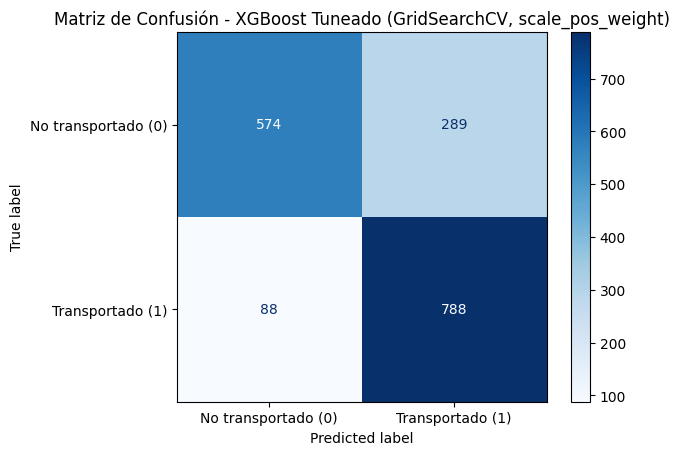

In [ ]:
xgb_lc.fit(X_train, y_train)
y_pred_anterior = xgb_lc.predict(X_test)

# Modelo tuneado: el ganador del GridSearchCV de la sección 2
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

evaluar_spaceship_model(y_test, y_pred_tuned, "XGBoost Tuneado (GridSearchCV, scale_pos_weight)")

Interpretación de la matriz de confusión — modelo tuneado

El Recall en test (89.95%) queda prácticamente idéntico al 90.38% obtenido en validación cruzada, y el F1 en test (0.8070) replica casi exactamente el F1 en CV (0.8073). Esto es una señal muy fuerte de que el tuning generaliza bien y no es un artefacto de sobreajuste a los folds de GridSearchCV: el modelo se comporta en datos nunca vistos igual que en la validación cruzada.

Del total de 876 pasajeros que sí fueron transportados en el conjunto de prueba, el modelo solo deja pasar 88 falsos negativos (10.05%), frente a los 143 que cometía el modelo anterior — una reducción del 38.5% en el error más costoso del problema. Cada uno de esos 88 casos es un pasajero que el sistema reporta como "a salvo" cuando en realidad fue transportado a la dimensión alternativa, por lo que no se despliega ningún esfuerzo de búsqueda y rescate para él: es el error que, según el criterio de negocio definido desde la sección 2, se debe minimizar por encima de todo.

La contraparte es que los falsos positivos suben de 194 a 289 (33% de los 863 pasajeros realmente no transportados). Este es el error "barato" del problema: significa movilizar recursos de búsqueda hacia alguien que no lo necesitaba, un costo operativo pero sin consecuencias irreversibles. Ese desplazamiento se refleja directamente en la caída de Specificity (77.52% → 66.51%) y Precision (79.07% → 73.17%): el modelo ahora es más "alarmista", clasifica más casos como positivos en general, y ese es exactamente el trade-off que scale_pos_weight=2 fue diseñado para producir.



In [ ]:
# 3.2 Comparativa: baseline vs modelo anterior vs modelo tuneado

resultados_finales = [
    calcular_metricas(y_test, y_pred_baseline, "Baseline (clase mayoritaria)"),
    calcular_metricas(y_test, y_pred_anterior,  "Modelo anterior (XGBoost, learning_rate=0.065)"),
    calcular_metricas(y_test, y_pred_tuned,     "Modelo tuneado (XGBoost + GridSearchCV)"),
]

tabla_final = pd.DataFrame(resultados_finales).set_index("Modelo").round(4)
tabla_final

,Accuracy,Precision,Recall,F1-score,Specificity,FN,FP
Modelo,,,,,,,
Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.6700,0.0000,0,863
"Modelo anterior (XGBoost, learning_rate=0.065)",0.8062,0.7907,0.8368,0.8131,0.7752,143,194
Modelo tuneado (XGBoost + GridSearchCV),0.7832,0.7317,0.8995,0.8070,0.6651,88,289


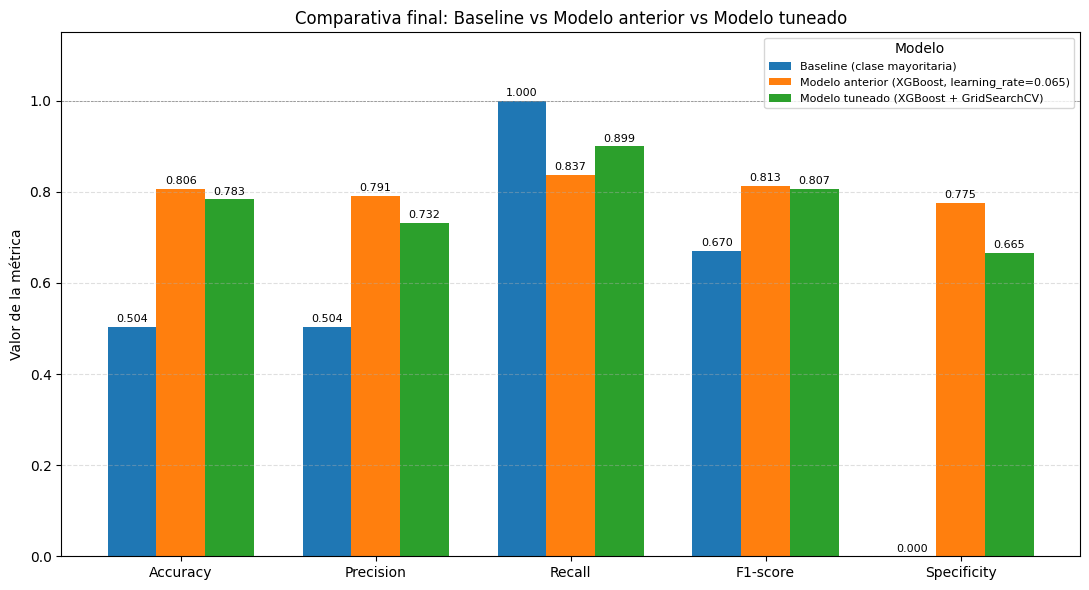

In [ ]:
# Visualización comparativa
metricas_plot = ["Accuracy", "Precision", "Recall", "F1-score", "Specificity"]
modelos_plot = tabla_final.index.tolist()

x = np.arange(len(metricas_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

for i, modelo in enumerate(modelos_plot):
    valores = tabla_final.loc[modelo, metricas_plot].values
    barras = ax.bar(x + (i - 1) * width, valores, width, label=modelo)
    ax.bar_label(barras, fmt="%.3f", padding=2, fontsize=8)

ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparativa final: Baseline vs Modelo anterior vs Modelo tuneado")
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot)
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color="gray", linewidth=0.5, linestyle="--")
ax.legend(title="Modelo", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Justificación: ¿el tuning mejoró el rendimiento y por qué?

El baseline sigue sin ser una alternativa real: su Recall de 1.0 es trivial (predice siempre "Transportado") y su Specificity de 0.0 confirma que no identifica ni un solo pasajero no transportado.

Comparando modelo anterior vs modelo tuneado, la respuesta depende de qué métrica se mire, y esa es justo la conclusión correcta a defender:

* **Recall** (la métrica prioritaria del equipo): subió de 83.68% a 89.95%, es decir, 6.3 puntos porcentuales, equivalentes a 55 pasajeros transportados adicionales que ahora sí son detectados (143 FN → 88 FN). Bajo el criterio de decisión que el equipo fijó desde la sección 2 de la entrega anterior, esto sí es una mejora clara y sustancial.
* **Precision y Specificity** bajaron (79.07%→73.17% y 77.52%→66.51%), porque el modelo ahora produce más falsos positivos (194→289). Este es el costo esperado y aceptado del trade-off, no un fallo del tuning.
* **F1-score** se mantuvo prácticamente igual (0.8131 → 0.8070, -0.6 puntos), lo que confirma que la ganancia en recall no vino de que el modelo colapsara prediciendo casi todo como positivo; el balance global precision-recall apenas se movió.
* **Accuracy** cayó de 80.62% a 78.32% (-2.3 puntos). Esta es la única métrica donde el modelo tuneado "empeora" de forma visible, y es exactamente por lo que el equipo decidió desde el principio no usar accuracy como criterio: con clases balanceadas, cambiar 55 FN por 95 FP adicionales mueve el acierto global hacia abajo, aunque el objetivo de negocio (minimizar FN) se haya cumplido mejor.

¿Por qué pasó lo que pasó? El diagnóstico de la sección 1 (curvas de aprendizaje/validación) ya mostraba que el modelo anterior había tocado un techo de sesgo, no de varianza ni de datos: max_depth, n_estimators y learning_rate ya estaban cerca de su óptimo individual con la función de pérdida estándar (peso implícito 1:1 entre clases). El GridSearchCV no mejoró el modelo ajustando capacidad, sino agregando scale_pos_weight, un parámetro que no busca "aprender mejor" el patrón subyacente sino desplazar deliberadamente el punto de operación del clasificador a lo largo de la frontera precision-recall, hacia el extremo que menos falsos negativos genera. El hecho de que el Recall y el F1 en test (0.8995 y 0.8070) prácticamente calquen los valores de CV (0.9038 y 0.8073) confirma que esta mejora es real y generaliza, no un artefacto de sobreajustar la búsqueda a los folds de validación cruzada. En resumen: el tuning sí mejoró el rendimiento en el sentido que le importa al negocio (menos pasajeros abandonados sin búsqueda), a costa de un trade-off consciente en accuracy, precision y specificity — que es exactamente la decisión que se buscaba tomar desde que se definió el Recall como métrica principal.

## 4. Componente individual

Esta sección tiene una subsección por cada integrante, identificada con su nombre completo. Cada integrante trabaja de forma independiente:

- Elige un modelo de familia distinta al del equipo.
- Tunealo con GridSearch o RandomizedSearch con al menos 3 hiperparámetros.
- Evalúalo con las mismas métricas del equipo.
- Compara sus resultados contra el modelo final del equipo: ¿cambiarías la decisión del equipo?, ¿por qué sí o por qué no?

### Saúl Caballero Castor ()

### Andrés Méndez Cortez ()

### Roberd Meza Sainz ()

### Santiago Serrano Montalvo ()

### Sofia Valeria Ramirez Moreno ()

In [ ]:
# Modelo final del equipo, como referencia fija para todas las subsecciones
xgb_final = XGBClassifier(
    min_child_weight=1, subsample=0.8, random_state=42, eval_metric='logloss',
    n_estimators=100, max_depth=2, learning_rate=0.08, scale_pos_weight=2
)
xgb_final.fit(X_train, y_train)
y_pred_equipo = xgb_final.predict(X_test)
metricas_equipo = calcular_metricas(y_test, y_pred_equipo, "Modelo final del equipo (XGBoost tuneado)")
metricas_equipo

{'Modelo': 'Modelo final del equipo (XGBoost tuneado)',
 'Accuracy': 0.7832087406555491,
 'Precision': 0.7316620241411328,
 'Recall': 0.8995433789954338,
 'F1-score': 0.8069636456733231,
 'Specificity': np.float64(0.6651216685979142),
 'FN': np.int64(88),
 'FP': np.int64(289)}

## 5. Exportar modelo y submission

- Exporta el modelo final con joblib o pickle.
- Carga el test.csv de Kaggle, aplica el mismo pipeline de preprocesamiento del avance 1 y genera el archivo de submission en el formato requerido (PassengerId, Transported).
- Verifica que el archivo tiene el shape correcto y que Transported es booleano (True/False).

6. Conclusión final del equipo

- ¿Qué aprendieron del comportamiento de los modelos sobre este dataset a lo largo de los tres avances?
- ¿Qué cambiarían en el pipeline de preprocesamiento sabiendo lo que saben ahora?
- ¿Qué esperan mejorar en la siguiente iteración?